[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/calculus/02_limits_and_continuity/first_principles.ipynb)

# Module 02 — Limits and Continuity

## 1. Why This Module Exists

Algebra evaluates. Analysis approaches. The gap between the two is where calculus lives.

Instantaneous velocity is the ratio $\frac{x(t+h) - x(t)}{h}$ at $h = 0$, which is $0/0$ and
therefore meaningless. The ratio nevertheless settles on a definite number as $h$ shrinks, and
the whole of differential calculus rests on making "settles on" precise.

The device that makes it precise is the $\varepsilon$-$\delta$ definition: a limit is a promise
that any accuracy demanded of the output can be bought by some accuracy imposed on the input.
Once that promise is written with quantifiers, it can be proved or refuted, never merely felt.

Continuity is the special case where the limit and the value agree. Two theorems follow that are
pure existence guarantees and are used constantly without being noticed: the **Intermediate Value
Theorem**, which is why bisection finds a root, and the **Extreme Value Theorem**, which is why a
minimizer exists before any algorithm looks for it.

This module proves both from the completeness axiom, adds the uniform-continuity refinement that
every numerical error bound silently uses, and checks each claim in running code.

## 2. Intuition

Picture the limit as a game with an adversary.

The adversary names a tolerance $\varepsilon \gt 0$: a horizontal band of half-width
$\varepsilon$ around the candidate value $L$. You must answer with a $\delta \gt 0$: a vertical
strip of half-width $\delta$ around $a$.

You win the round when the graph of $f$, restricted to the strip and with the single point $x = a$
deleted, stays inside the band. The limit is $L$ exactly when you can win **every** round.

Two features of the game are the whole subject. First, $\delta$ is allowed to depend on
$\varepsilon$ and on $a$, and on nothing else. Second, the point $x = a$ is punched out, which is
why $\lim_{x \to a} f(x)$ can exist where $f(a)$ does not.

Continuity is the extra clause that the punched-out point may be put back: $f(a)$ is defined and
lies at the centre of every band you were asked to hit.

The first code cell is the notebook preamble. It fixes the plotting defaults, seeds the single
random generator used anywhere below, and prints the two floating-point constants that later
residual claims are measured against.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

EPS = np.finfo(float).eps          # machine epsilon, 2^-52
UNIT_ROUNDOFF = 0.5 * EPS          # u = 2^-53, the constant in the standard model
print(f"machine epsilon eps_mach = {EPS:.6e}   (2^-52)")
print(f"unit roundoff  u         = {UNIT_ROUNDOFF:.6e}   (2^-53)")

machine epsilon eps_mach = 2.220446e-16   (2^-52)
unit roundoff  u         = 1.110223e-16   (2^-53)


Every residual reported below is quoted as a multiple of $\varepsilon_{\mathrm{mach}}$, and every
finite-difference step size is written in terms of $u$, as fixed in
[the notation register](../../docs/notation.md).

The next cell draws the game. It plots $f(x) = x^{2}$ near $a = 3$, shades the band
$\lvert y - 9 \rvert \lt \varepsilon$ for $\varepsilon = 0.01$, and shades the strip
$0 \lt \lvert x - 3 \rvert \lt \delta$ for the answer $\delta = \varepsilon / 7$ derived in
Example 6.1. It also draws the *largest* strip that would still win the round, so the two can be
compared.

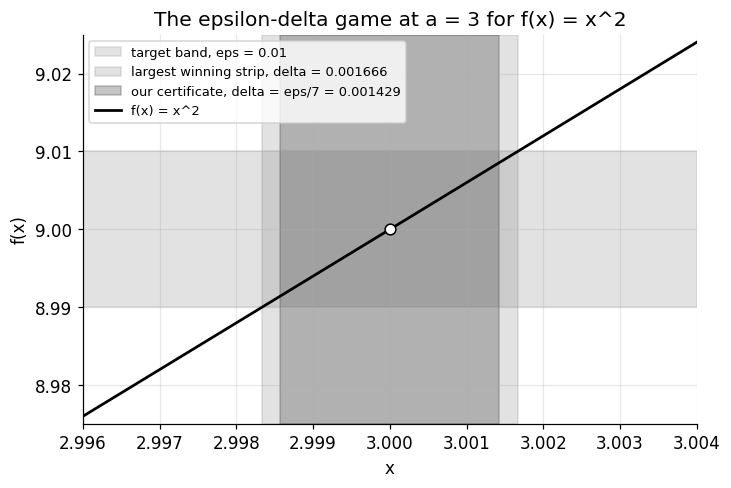

sup |x^2 - 9| over |x - 3| <= eps/7 : 0.00857347   (must stay below eps = 0.01)
sharp delta / our delta            : 1.166343


In [2]:
a, L, eps_band = 3.0, 9.0, 0.01
delta_ours = min(1.0, eps_band / 7.0)                 # the certificate of Example 6.1
delta_max = min(a - np.sqrt(L - eps_band), np.sqrt(L + eps_band) - a)   # the sharp one

xs = np.linspace(a - 0.004, a + 0.004, 1200)
fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.axhspan(L - eps_band, L + eps_band, color="0.75", alpha=0.45,
           label=f"target band, eps = {eps_band}")
ax.axvspan(a - delta_max, a + delta_max, color="0.55", alpha=0.25,
           label=f"largest winning strip, delta = {delta_max:.6f}")
ax.axvspan(a - delta_ours, a + delta_ours, color="0.25", alpha=0.30,
           label=f"our certificate, delta = eps/7 = {delta_ours:.6f}")
ax.plot(xs, xs ** 2, lw=1.8, color="k", label="f(x) = x^2")
ax.plot([a], [L], "wo", mec="k", ms=7, zorder=5)
ax.set_xlim(xs[0], xs[-1])
ax.set_ylim(L - 0.025, L + 0.025)
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_title("The epsilon-delta game at a = 3 for f(x) = x^2")
ax.legend(loc="upper left", fontsize=8.5)
plt.show()

x_test = np.linspace(a - delta_ours, a + delta_ours, 200001)
worst = np.abs(x_test ** 2 - L).max()
print(f"sup |x^2 - 9| over |x - 3| <= eps/7 : {worst:.8f}   (must stay below eps = {eps_band})")
print(f"sharp delta / our delta            : {delta_max / delta_ours:.6f}")
assert worst < eps_band

The black curve never leaves the grey band while it is inside the dark strip, so
$\delta = \varepsilon/7$ wins this round: the worst deviation it permits is $0.00857$, comfortably
under the demanded $0.01$.

The sharp answer is only $1.166$ times larger. An $\varepsilon$-$\delta$ certificate does not have
to be optimal; it has to be *valid* and *explicit*.

## 3. Definitions

Throughout, $D \subseteq \mathbb{R}$, $f : D \to \mathbb{R}$, and $a$ is a point such that some
punctured interval $(a - r, a + r) \setminus \lbrace a \rbrace$ lies in $D$. Absolute values are
written $\lvert \cdot \rvert$ and the limit quantifiers are $\varepsilon$ and $\delta$, never
$\epsilon$, as fixed in [the notation register](../../docs/notation.md).

### Definition 3.1 — Limit of a function at a point

We write $\lim_{x \to a} f(x) = L$ when

$$
\forall \varepsilon \gt 0 \ \ \exists \delta \gt 0 \ \ \forall x \in D : \ 0 \lt \lvert x - a \rvert \lt \delta \implies \lvert f(x) - L \rvert \lt \varepsilon .
$$

The clause $0 \lt \lvert x - a \rvert$ punches out $x = a$, so the value $f(a)$ — if it exists at
all — is irrelevant to the limit.

The order of the quantifiers is the definition. Swapping $\forall \varepsilon$ and
$\exists \delta$ produces a statement that is false for every non-constant function.

### Definition 3.2 — One-sided limits

$\lim_{x \to a^{+}} f(x) = L$ means: for every $\varepsilon \gt 0$ there is $\delta \gt 0$ with
$0 \lt x - a \lt \delta \implies \lvert f(x) - L \rvert \lt \varepsilon$.

$\lim_{x \to a^{-}} f(x) = L$ is the same with $0 \lt a - x \lt \delta$.

The two-sided limit exists and equals $L$ if and only if both one-sided limits exist and equal
$L$, because the punctured neighbourhood is the union of the two half-neighbourhoods.

### Definition 3.3 — Infinite limits and limits at infinity

$\lim_{x \to a} f(x) = +\infty$ means: for every $M \gt 0$ there is $\delta \gt 0$ with
$0 \lt \lvert x - a \rvert \lt \delta \implies f(x) \gt M$.

$\lim_{x \to +\infty} f(x) = L$ means: for every $\varepsilon \gt 0$ there is $N$ with
$x \gt N \implies \lvert f(x) - L \rvert \lt \varepsilon$.

Neither is a limit in the sense of Definition 3.1; both are separate definitions that reuse the
same quantifier pattern with a different notion of "close".

### Definition 3.4 — Continuity at a point and on a set

$f$ is **continuous at** $a \in D$ when

$$
\forall \varepsilon \gt 0 \ \ \exists \delta \gt 0 \ \ \forall x \in D : \ \lvert x - a \rvert \lt \delta \implies \lvert f(x) - f(a) \rvert \lt \varepsilon .
$$

Equivalently, when $a$ is not isolated in $D$: $f(a)$ is defined, $\lim_{x \to a} f(x)$ exists,
and the two agree.

$f$ is **continuous on** $S \subseteq D$ when it is continuous at every point of $S$. Note that
the punctured clause has vanished, because $x = a$ now satisfies the conclusion automatically.

### Definition 3.5 — Upper and lower limits at a point

For $f$ bounded near $a$, the **upper** and **lower limits** at $a$ are

$$
\limsup_{x \to a} f(x) = \lim_{r \to 0^{+}} \ \sup \lbrace f(x) : 0 \lt \lvert x - a \rvert \lt r \rbrace,
\qquad
\liminf_{x \to a} f(x) = \lim_{r \to 0^{+}} \ \inf \lbrace f(x) : 0 \lt \lvert x - a \rvert \lt r \rbrace .
$$

Both limits exist because the supremum is non-increasing and the infimum non-decreasing as $r$
shrinks, and both are bounded. The ordinary limit exists exactly when the two agree, and then all
three coincide.

### Definition 3.6 — Classification of discontinuities

Let $f$ fail to be continuous at $a$. Exactly one of the following holds.

- **Removable**: $\lim_{x \to a} f(x)$ exists and is finite, but either $f(a)$ is undefined or
  $f(a)$ differs from that limit.
- **Jump**: both one-sided limits exist and are finite, and $L_{+} \neq L_{-}$; the **jump** is
  $\lvert L_{+} - L_{-} \rvert$.
- **Essential**: neither of the above — at least one one-sided limit fails to exist as a finite
  number.

Essential discontinuities split into two sub-cases, which are *not* a third and fourth class:

- **infinite**, when a one-sided limit is $+\infty$ or $-\infty$, as for $1/(x-1)^{2}$ at $1$;
- **oscillatory**, when a one-sided limit fails to exist while $f$ stays bounded, as for
  $\sin(1/x)$ at $0$, where $\liminf = -1 \lt 1 = \limsup$ by Definition 3.5.

### Definition 3.7 — Uniform continuity and Lipschitz continuity

$f$ is **uniformly continuous on** $S$ when

$$
\forall \varepsilon \gt 0 \ \ \exists \delta \gt 0 \ \ \forall x, y \in S : \ \lvert x - y \rvert \lt \delta \implies \lvert f(x) - f(y) \rvert \lt \varepsilon .
$$

The only difference from Definition 3.4 is that $\forall x$ has moved **in front of**
$\exists \delta$: one $\delta$ must serve the whole of $S$ at once.

$f$ is **Lipschitz on** $S$ with constant $K$ when
$\lvert f(x) - f(y) \rvert \le K \lvert x - y \rvert$ for all $x, y \in S$.

### Definition 3.8 — Asymptotic notation

As $x \to a$ (where $a$ may be $\pm\infty$):

- $f = O(g)$ when there are $C \gt 0$ and a punctured neighbourhood of $a$ on which
  $\lvert f \rvert \le C \lvert g \rvert$;
- $f = o(g)$ when $f/g \to 0$;
- $f \sim g$ when $f/g \to 1$.

The capitals are bare, never $\mathcal{O}$. Note that $f = O(g)$ is an inequality in disguise and
is not symmetric: $x = O(x^{2})$ is false as $x \to 0$ and true as $x \to \infty$.

## 4. Main Results

Theorems 4.1 to 4.4 are the local calculus of limits: uniqueness, algebra, the squeeze, and the
translation into sequences that converts every limit question into a sequence question.

Theorem 4.5 (**IVT**) and Theorem 4.7 (**EVT**) are the two results the module exists for. Both
are existence theorems, both are consequences of the completeness of $\mathbb{R}$, and both fail
loudly the moment a hypothesis is dropped.

Theorem 4.8 (**Heine-Cantor**) upgrades continuity to uniform continuity on a compact interval and
is the hypothesis every numerical error bound actually needs. Theorem 4.9 restates continuity
without $\varepsilon$ at all. Theorem 4.10 supplies the trigonometric limit that differential
calculus starts from, and Propositions 4.11 to 4.13 collect the facts most often misremembered.

### Theorem 4.1 — Uniqueness of the limit

If $\lim_{x \to a} f(x) = L_{1}$ and $\lim_{x \to a} f(x) = L_{2}$, then $L_{1} = L_{2}$.

**Hypotheses.** Only Definition 3.1. The proof needs $a$ to be approachable — every punctured
neighbourhood of $a$ must contain a point of $D$ — otherwise the implication in Definition 3.1 is
vacuously true for every $L$ and uniqueness fails.

Proved as Proof 5.1.

### Theorem 4.2 — Algebra of limits

Let $\lim_{x \to a} f(x) = L$ and $\lim_{x \to a} g(x) = M$. Then

$$
\lim_{x \to a} \bigl( f(x) + g(x) \bigr) = L + M, \qquad
\lim_{x \to a} f(x) g(x) = LM,
$$

and if $M \neq 0$,

$$
\lim_{x \to a} \frac{f(x)}{g(x)} = \frac{L}{M} .
$$

**Hypotheses.** Both limits must exist *separately*; $M \neq 0$ is needed for the quotient, and
without it the statement is not merely unprovable but false, since $f/g$ may tend to any value or
to none. Existence of the sum limit does not imply existence of the summands' limits: take
$f = \mathbf{1}_{\mathbb{Q}}$ and $g = 1 - f$.

Proved as Proof 5.2.

### Theorem 4.3 — Squeeze theorem

Suppose $g(x) \le f(x) \le h(x)$ for all $x$ in some punctured neighbourhood of $a$, and

$$
\lim_{x \to a} g(x) = \lim_{x \to a} h(x) = L .
$$

Then $\lim_{x \to a} f(x)$ exists and equals $L$.

**Hypotheses.** The two outer limits must be *equal*; if they differ the conclusion is false, as
$-1 \le \sin(1/x) \le 1$ shows at $a = 0$. The inequality is only needed near $a$, never at $a$.

**Interpretation.** This is the only tool in the module that produces the existence of a limit
without first guessing a $\delta$: existence is inherited from the envelopes.

Proved as Proof 5.3.

### Theorem 4.4 — Sequential criterion

$\lim_{x \to a} f(x) = L$ if and only if for **every** sequence $(x_{n})$ in
$D \setminus \lbrace a \rbrace$ with $x_{n} \to a$ one has $f(x_{n}) \to L$.

**Hypotheses.** None beyond Definition 3.1. The word *every* is load-bearing: one convergent
sequence proves nothing, whereas two sequences with different limits of $f(x_{n})$ refute the
limit outright.

**Interpretation.** This is the cheapest way to prove a limit does **not** exist, and it is what
Example 6.3 uses on $\sin(1/x)$.

Proved as Proof 5.4.

### Theorem 4.5 — Intermediate Value Theorem

Let $f : [a, b] \to \mathbb{R}$ be continuous on the **whole** closed interval $[a, b]$, and let
$d$ lie strictly between $f(a)$ and $f(b)$. Then there exists $c \in (a, b)$ with

$$
f(c) = d .
$$

**Hypotheses, one sentence each.** Continuity at *every* point of $[a, b]$ is needed because a
single removable or jump discontinuity can straddle $d$ without ever attaining it. The interval
must be an interval — a connected domain — since $x \mapsto 1/x$ on
$[-1, 0) \cup (0, 1]$ changes sign without a root. The endpoints must be included, since the
argument locates $c$ as a supremum inside $[a,b]$ and then evaluates $f$ there.

**Interpretation.** IVT says a continuous image of an interval is an interval: continuity cannot
tear the line. Every bracketing root-finder is this theorem run as an algorithm.

Proved as Proof 5.5.

### Lemma 4.6 — Bolzano-Weierstrass on a closed bounded interval

Every sequence $(x_{n})$ with $x_{n} \in [a, b]$ has a subsequence converging to a limit in
$[a, b]$.

**Hypotheses.** Boundedness and closedness both. On $(0, 1]$ the sequence $x_{n} = 1/n$ has no
subsequence with a limit *in the set*; on $[0, \infty)$ the sequence $x_{n} = n$ has no convergent
subsequence at all.

This lemma is stated and proved here rather than cited, because sequences and series are developed
downstream in
[calculus/08](../08_sequences_series_convergence/first_principles.ipynb) and a forward citation
would leave Theorem 4.7 unproved.

Proved as Proof 5.6.

### Theorem 4.7 — Extreme Value Theorem

Let $f : [a, b] \to \mathbb{R}$ be continuous, with $a \lt b$ finite. Then $f$ is bounded and
attains both bounds: there are $x_{\min}, x_{\max} \in [a, b]$ with

$$
f(x_{\min}) \le f(x) \le f(x_{\max}) \qquad \text{for all } x \in [a, b] .
$$

**Hypotheses, one sentence each.** Continuity is needed because $f(x) = x$ for $x \lt 1$,
$f(1) = 0$ is bounded on $[0,1]$ with supremum $1$ that it never attains. Closedness is needed
because $f(x) = x$ on $[0, 1)$ has supremum $1$ and no maximum. Boundedness of the interval is
needed because $f(x) = x$ on $[0, \infty)$ is unbounded.

**Interpretation.** Combined with Theorem 4.5, the image of $[a,b]$ under a continuous $f$ is
exactly the closed interval $[\min f, \max f]$: continuous images of compact intervals are compact
intervals. Every optimization argument that says "a minimizer exists" before running an algorithm
is quoting this theorem.

Proved as Proof 5.7.

### Theorem 4.8 — Heine-Cantor

If $f$ is continuous on the closed bounded interval $[a, b]$, then $f$ is uniformly continuous on
$[a, b]$.

**Hypotheses.** Compactness of the domain is the entire content: $x \mapsto x^{2}$ is continuous
on $[0, \infty)$ and not uniformly continuous there, and $x \mapsto 1/x$ is continuous on $(0, 1]$
and not uniformly continuous there. Both failures are run in Section 7.

**Interpretation.** Uniform continuity is what lets a single grid spacing control the error
everywhere at once. Every quadrature and finite-difference error bound of the form
"$\lvert f(x) - f(y) \rvert \lt \varepsilon$ whenever the mesh is finer than $\delta$" is using
this theorem, usually silently.

Proved as Proof 5.8.

### Theorem 4.9 — Topological characterization of continuity

$f : \mathbb{R} \to \mathbb{R}$ is continuous at every point if and only if $f^{-1}(V)$ is open
for every open $V \subseteq \mathbb{R}$.

**Hypotheses.** The statement is about continuity on the *whole* domain; there is no pointwise
version, because openness is not a pointwise property. Stated on a subdomain $D$, "open" must be
read relative to $D$.

**Interpretation.** The definition of continuity survives with no metric at all — only a notion of
open set. That is what makes continuity meaningful on graphs, manifolds and function spaces.

Proved as Proof 5.9.

### Theorem 4.10 — The fundamental trigonometric limits

$$
\lim_{x \to 0} \frac{\sin x}{x} = 1, \qquad \lim_{x \to 0} \frac{1 - \cos x}{x^{2}} = \frac{1}{2} .
$$

**Hypotheses.** The angle $x$ must be in radians, and *radian* must be defined by arc length or,
equivalently, as twice the area of the unit sector it subtends. Under any other convention the
first limit picks up a constant factor, and the proof below would be circular.

**Interpretation.** The first limit is exactly the statement $\sin'(0) = 1$; the second is
$\cos''(0) = -1$. Every derivative of a trigonometric function is downstream of these two numbers.

Proved as Proof 5.10.

### Proposition 4.11 — Lipschitz, uniform, pointwise

On any $S \subseteq \mathbb{R}$,

$$
\text{Lipschitz} \implies \text{uniformly continuous} \implies \text{continuous},
$$

and both implications are strict: $\sqrt{x}$ on $[0, 1]$ is uniformly continuous and not
Lipschitz, and $x^{2}$ on $[0, \infty)$ is continuous and not uniformly continuous.

**Interpretation.** The three notions differ in *what $\delta$ may depend on*: on $\varepsilon$ and
the point, on $\varepsilon$ alone, or on $\varepsilon$ alone and linearly.

Proved as Proof 5.11.

### Proposition 4.12 — Discontinuities of a monotone function

Let $f$ be non-decreasing on $(a, b)$. Then both one-sided limits exist at every interior point,
so every discontinuity is a jump, and the set of discontinuities is at most countable.

**Hypotheses.** Monotonicity only; no continuity is assumed anywhere. The conclusion is false
without it: the Dirichlet function is discontinuous at every point of an uncountable set.

**Interpretation.** A cumulative distribution function is non-decreasing, so it can only jump, and
only countably often — which is why a distribution has at most countably many atoms.

Proved as Proof 5.12.

### Proposition 4.13 — Limits of composites

If $\lim_{x \to a} g(x) = L$ and $f$ is **continuous at** $L$, then
$\lim_{x \to a} f(g(x)) = f(L)$.

**Hypotheses.** Continuity of $f$ at $L$ cannot be weakened to
$\lim_{y \to L} f(y) = M$. With

$$
g \equiv 0, \qquad f(y) = \begin{cases} 1 & y \neq 0 \\ 0 & y = 0 \end{cases}, \qquad a = L = 0,
$$

one has $\lim_{y \to 0} f(y) = 1$ but $f(g(x)) \equiv 0$, so the composite limit is $0$, not $1$.
Section 7 runs this case.

**Interpretation.** Substitution inside a limit is legal only when the outer function cannot see
the punctured point — that is, only when it is continuous there.

Proved as Proof 5.13.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1, uniqueness)

Suppose $L_{1} \neq L_{2}$ and set $\varepsilon = \tfrac{1}{2}\lvert L_{1} - L_{2} \rvert \gt 0$.

Definition 3.1 supplies $\delta_{1}$ and $\delta_{2}$ with

$$
0 \lt \lvert x - a \rvert \lt \delta_{1} \implies \lvert f(x) - L_{1} \rvert \lt \varepsilon,
\qquad
0 \lt \lvert x - a \rvert \lt \delta_{2} \implies \lvert f(x) - L_{2} \rvert \lt \varepsilon .
$$

Put $\delta = \min(\delta_{1}, \delta_{2}) \gt 0$. Because $a$ is approachable, some $x \in D$
satisfies $0 \lt \lvert x - a \rvert \lt \delta$; fix one.

The triangle inequality then gives

$$
\lvert L_{1} - L_{2} \rvert \le \lvert L_{1} - f(x) \rvert + \lvert f(x) - L_{2} \rvert \lt 2\varepsilon = \lvert L_{1} - L_{2} \rvert,
$$

a contradiction. $\blacksquare$

**Interpretation.** The existence of one admissible $x$ is where approachability enters; without
it no contradiction can be produced and "the" limit is not well defined.

### Proof 5.2 (of Theorem 4.2, algebra of limits)

**Sum.** Given $\varepsilon \gt 0$ choose $\delta_{1}, \delta_{2}$ making
$\lvert f - L \rvert \lt \varepsilon/2$ and $\lvert g - M \rvert \lt \varepsilon/2$, and take
$\delta = \min(\delta_{1}, \delta_{2})$. Then

$$
\lvert (f + g) - (L + M) \rvert \le \lvert f - L \rvert + \lvert g - M \rvert \lt \varepsilon .
$$

**Product.** Split the error so that each piece contains exactly one small factor:

$$
\lvert fg - LM \rvert = \lvert g(f - L) + L(g - M) \rvert \le \lvert g \rvert \, \lvert f - L \rvert + \lvert L \rvert \, \lvert g - M \rvert .
$$

The factor $\lvert g \rvert$ must first be bounded. Applying the definition to $g$ with
$\varepsilon = 1$ gives $\delta_{1}$ with $\lvert g - M \rvert \lt 1$, hence
$\lvert g \rvert \lt \lvert M \rvert + 1 =: B$ on that neighbourhood.

Now given $\varepsilon \gt 0$ choose $\delta_{2}$ with
$\lvert f - L \rvert \lt \varepsilon / (2B)$ and $\delta_{3}$ with
$\lvert g - M \rvert \lt \varepsilon / \bigl(2(\lvert L \rvert + 1)\bigr)$.

With $\delta = \min(\delta_{1}, \delta_{2}, \delta_{3})$,

$$
\lvert fg - LM \rvert \lt B \cdot \frac{\varepsilon}{2B} + \lvert L \rvert \cdot \frac{\varepsilon}{2(\lvert L \rvert + 1)} \lt \frac{\varepsilon}{2} + \frac{\varepsilon}{2} = \varepsilon .
$$

The denominator $\lvert L \rvert + 1$ rather than $\lvert L \rvert$ is what keeps the bound valid
when $L = 0$.

**Reciprocal.** Assume $M \neq 0$. Applying the definition to $g$ with
$\varepsilon = \lvert M \rvert / 2$ gives $\delta_{4}$ on which
$\lvert g \rvert \gt \lvert M \rvert / 2$, so $1/g$ is defined there and

$$
\left\lvert \frac{1}{g} - \frac{1}{M} \right\rvert = \frac{\lvert M - g \rvert}{\lvert g \rvert \, \lvert M \rvert} \lt \frac{2}{\lvert M \rvert^{2}} \, \lvert g - M \rvert .
$$

Choosing $\delta_{5}$ with $\lvert g - M \rvert \lt \varepsilon \lvert M \rvert^{2} / 2$ and
intersecting finishes it. The quotient rule is the product rule applied to $f \cdot (1/g)$.
$\blacksquare$

### Proof 5.3 (of Theorem 4.3, squeeze)

Let $\varepsilon \gt 0$. Choose $\delta_{1}$ with
$0 \lt \lvert x - a \rvert \lt \delta_{1} \implies \lvert g(x) - L \rvert \lt \varepsilon$, and
$\delta_{2}$ likewise for $h$, and let $\delta_{3}$ be the radius on which the sandwich
$g \le f \le h$ holds.

Put $\delta = \min(\delta_{1}, \delta_{2}, \delta_{3})$. For $0 \lt \lvert x - a \rvert \lt \delta$,

$$
L - \varepsilon \lt g(x) \le f(x) \le h(x) \lt L + \varepsilon,
$$

which is exactly $\lvert f(x) - L \rvert \lt \varepsilon$. $\blacksquare$

**Interpretation.** Nothing was assumed about $f$ beyond the sandwich. That is why the theorem
can create a limit for a function as badly behaved as $x^{2}\sin(1/x)$.

### Proof 5.4 (of Theorem 4.4, sequential criterion)

**($\Rightarrow$)** Assume $\lim_{x \to a} f(x) = L$ and let $x_{n} \to a$ with
$x_{n} \neq a$. Given $\varepsilon \gt 0$, take the $\delta$ from Definition 3.1, then take $N$
with $\lvert x_{n} - a \rvert \lt \delta$ for $n \gt N$. Since also $x_{n} \neq a$, the hypothesis
$0 \lt \lvert x_{n} - a \rvert \lt \delta$ holds, so $\lvert f(x_{n}) - L \rvert \lt \varepsilon$
for all $n \gt N$.

**($\Leftarrow$)** Contrapositive. Suppose the limit statement fails. Negating Definition 3.1:
there is $\varepsilon_{0} \gt 0$ such that for **every** $\delta \gt 0$ some $x$ satisfies
$0 \lt \lvert x - a \rvert \lt \delta$ and $\lvert f(x) - L \rvert \ge \varepsilon_{0}$.

Apply this with $\delta = 1/n$ for each $n \in \mathbb{N}$, $n \ge 1$, and call the resulting
point $x_{n}$. Then $0 \lt \lvert x_{n} - a \rvert \lt 1/n$, so $x_{n} \to a$ with
$x_{n} \neq a$, while $\lvert f(x_{n}) - L \rvert \ge \varepsilon_{0}$ for every $n$, so
$f(x_{n}) \not\to L$.

That is one sequence violating the right-hand side, which is therefore false. $\blacksquare$

**Interpretation.** The backward direction is where the strength lies: a single badly chosen
sequence is enough to destroy a limit, and Example 6.3 builds two.

### Proof 5.5 (of Theorem 4.5, the Intermediate Value Theorem)

Assume $f(a) \lt d \lt f(b)$; the case $f(b) \lt d \lt f(a)$ follows by applying the result to
$-f$ and $-d$.

**Step 1 — the set.** Put

$$
S = \lbrace x \in [a, b] : f(x) \lt d \rbrace .
$$

$S$ contains $a$, so it is non-empty, and it is bounded above by $b$. By the completeness axiom
$c = \sup S$ exists and $c \in [a, b]$.

**Step 2 — the endpoints are excluded.** Continuity at $a$ with
$\varepsilon = d - f(a) \gt 0$ gives $\delta_{a} \gt 0$ such that $f(x) \lt d$ for all
$x \in [a, a + \delta_{a}) \cap [a,b]$; hence $c \ge a + \delta_{a}/2 \gt a$.

Continuity at $b$ with $\varepsilon = f(b) - d \gt 0$ gives $\delta_{b} \gt 0$ such that
$f(x) \gt d$ for all $x \in (b - \delta_{b}, b] \cap [a,b]$; hence every element of $S$ is at most
$b - \delta_{b}$, so $c \le b - \delta_{b} \lt b$.

Therefore $c \in (a, b)$, and in particular a whole two-sided neighbourhood of $c$ lies inside
$[a, b]$. This step is what makes the two cases below legitimate; without it the points
$c \pm \delta/2$ used there need not belong to the domain.

**Step 3 — rule out $f(c) \lt d$.** Suppose $f(c) \lt d$ and set
$\varepsilon = d - f(c) \gt 0$. Continuity at $c$ gives $\delta \gt 0$, which we may shrink so
that $(c - \delta, c + \delta) \subseteq (a, b)$ by Step 2, with

$$
\lvert x - c \rvert \lt \delta \implies f(x) \lt f(c) + \varepsilon = d .
$$

Then $c + \delta/2 \in [a,b]$ and $f(c + \delta/2) \lt d$, so $c + \delta/2 \in S$, contradicting
$c = \sup S$.

**Step 4 — rule out $f(c) \gt d$.** Suppose $f(c) \gt d$ and set
$\varepsilon = f(c) - d \gt 0$. Continuity at $c$ gives $\delta \gt 0$, again shrunk so that
$(c - \delta, c + \delta) \subseteq (a,b)$, with

$$
\lvert x - c \rvert \lt \delta \implies f(x) \gt f(c) - \varepsilon = d .
$$

So no point of $(c - \delta, c]$ lies in $S$. Since $c = \sup S$, there are points of $S$
arbitrarily close to $c$ from below — in particular some $s \in S$ with
$c - \delta \lt s \le c$ — and $f(s) \lt d$ contradicts the display.

**Conclusion.** $f(c)$ is neither less than nor greater than $d$, so $f(c) = d$ with
$c \in (a, b)$. $\blacksquare$

**Interpretation.** Completeness enters exactly once, at the supremum in Step 1. Over
$\mathbb{Q}$ the theorem is false: $f(x) = x^{2} - 2$ is continuous on $[1, 2] \cap \mathbb{Q}$,
changes sign, and has no rational root.

### Proof 5.6 (of Lemma 4.6, Bolzano-Weierstrass)

Repeated bisection. Set $I_{0} = [a, b]$. Given $I_{k}$ containing $x_{n}$ for infinitely many
indices $n$, split $I_{k}$ at its midpoint; at least one closed half again contains $x_{n}$ for
infinitely many $n$, and we call it $I_{k+1}$.

This produces nested closed intervals $I_{0} \supseteq I_{1} \supseteq \cdots$ with

$$
\operatorname{length}(I_{k}) = \frac{b - a}{2^{k}} \longrightarrow 0 .
$$

Write $I_{k} = [\alpha_{k}, \beta_{k}]$. The $\alpha_{k}$ are non-decreasing and bounded above by
$b$, so $\xi = \sup_{k} \alpha_{k}$ exists by completeness, and $\alpha_{k} \le \xi \le \beta_{k}$
for every $k$ because each $\beta_{k}$ is an upper bound for all the $\alpha_{j}$. Hence
$\xi \in \bigcap_{k} I_{k}$ and $\xi \in [a, b]$.

Now choose indices $n_{1} \lt n_{2} \lt \cdots$ with $x_{n_{k}} \in I_{k}$, which is possible
because each $I_{k}$ holds infinitely many terms. Then

$$
\lvert x_{n_{k}} - \xi \rvert \le \operatorname{length}(I_{k}) = \frac{b - a}{2^{k}} \to 0,
$$

so $x_{n_{k}} \to \xi \in [a, b]$. $\blacksquare$

### Proof 5.7 (of Theorem 4.7, the Extreme Value Theorem)

**Step 1 — boundedness.** Suppose $f$ is unbounded above. Then for each $n \ge 1$ there is
$x_{n} \in [a, b]$ with $f(x_{n}) \gt n$.

By Lemma 4.6 some subsequence $x_{n_{k}} \to \xi \in [a, b]$. Continuity of $f$ at $\xi$ plus
Theorem 4.4 gives $f(x_{n_{k}}) \to f(\xi)$, a finite number; but $f(x_{n_{k}}) \gt n_{k} \to
\infty$, so the sequence $f(x_{n_{k}})$ is unbounded and cannot converge. Contradiction.

The same argument applied to $-f$ bounds $f$ below.

**Step 2 — the supremum is attained.** Let $M = \sup_{[a,b]} f$, finite by Step 1. For each
$n \ge 1$ the number $M - 1/n$ is not an upper bound, so there is $y_{n} \in [a, b]$ with

$$
M - \frac{1}{n} \lt f(y_{n}) \le M .
$$

By Lemma 4.6 a subsequence $y_{n_{k}} \to x_{\max} \in [a, b]$. Continuity and Theorem 4.4 give
$f(y_{n_{k}}) \to f(x_{\max})$, while the display forces $f(y_{n_{k}}) \to M$. By Theorem 4.1
these two limits agree, so $f(x_{\max}) = M$.

Applying Step 2 to $-f$ produces $x_{\min}$. $\blacksquare$

**Interpretation.** Boundedness and attainment are genuinely two steps: a function can be bounded
and miss its supremum, which is precisely the discontinuous counterexample run in Section 7.

### Proof 5.8 (of Theorem 4.8, Heine-Cantor)

Suppose $f$ is continuous on $[a, b]$ but not uniformly continuous. Negating Definition 3.7,
there is $\varepsilon_{0} \gt 0$ such that for every $\delta \gt 0$ some pair $x, y \in [a,b]$ has
$\lvert x - y \rvert \lt \delta$ and $\lvert f(x) - f(y) \rvert \ge \varepsilon_{0}$.

Take $\delta = 1/n$ and call the pair $(x_{n}, y_{n})$, so that

$$
\lvert x_{n} - y_{n} \rvert \lt \frac{1}{n}, \qquad \lvert f(x_{n}) - f(y_{n}) \rvert \ge \varepsilon_{0} .
$$

By Lemma 4.6 there is a subsequence $x_{n_{k}} \to \xi \in [a, b]$. Since
$\lvert y_{n_{k}} - \xi \rvert \le \lvert y_{n_{k}} - x_{n_{k}} \rvert + \lvert x_{n_{k}} - \xi \rvert \to 0$,
the matching subsequence $y_{n_{k}}$ converges to the same $\xi$.

Continuity of $f$ at $\xi$ and Theorem 4.4 give $f(x_{n_{k}}) \to f(\xi)$ and
$f(y_{n_{k}}) \to f(\xi)$, hence

$$
\lvert f(x_{n_{k}}) - f(y_{n_{k}}) \rvert \longrightarrow 0,
$$

contradicting $\lvert f(x_{n_{k}}) - f(y_{n_{k}}) \rvert \ge \varepsilon_{0} \gt 0$ for all $k$.
$\blacksquare$

**Interpretation.** Compactness is used exactly once, to extract the convergent subsequence. Drop
it and the two sequences can run off to infinity while staying close to each other, which is
exactly how $x^{2}$ defeats uniformity on $[0, \infty)$.

### Proof 5.9 (of Theorem 4.9, topological characterization)

**($\Rightarrow$)** Let $f$ be continuous everywhere, let $V$ be open, and let
$x_{0} \in f^{-1}(V)$. Since $V$ is open there is $\varepsilon \gt 0$ with
$(f(x_{0}) - \varepsilon, f(x_{0}) + \varepsilon) \subseteq V$.

Continuity at $x_{0}$ supplies $\delta \gt 0$ with
$\lvert x - x_{0} \rvert \lt \delta \implies \lvert f(x) - f(x_{0}) \rvert \lt \varepsilon$, so
$(x_{0} - \delta, x_{0} + \delta) \subseteq f^{-1}(V)$. Every point of $f^{-1}(V)$ is interior, so
the preimage is open.

**($\Leftarrow$)** Fix $x_{0}$ and $\varepsilon \gt 0$. The interval
$V = (f(x_{0}) - \varepsilon, f(x_{0}) + \varepsilon)$ is open, so $f^{-1}(V)$ is open and
contains $x_{0}$. Hence some $\delta \gt 0$ has
$(x_{0} - \delta, x_{0} + \delta) \subseteq f^{-1}(V)$, which says precisely that
$\lvert x - x_{0} \rvert \lt \delta \implies \lvert f(x) - f(x_{0}) \rvert \lt \varepsilon$.
$\blacksquare$

**Interpretation.** The $\varepsilon$ became "an open set around the output" and the $\delta$
became "an open set around the input"; nothing else changed.

### Proof 5.10 (of Theorem 4.10, the trigonometric limits)

**The definition of the angle.** Take $x \in (0, \pi/2)$ to be *defined* as twice the area of the
unit-circle sector it subtends, equivalently as the arc length it subtends. This is the point at
which the argument could become circular, and fixing the definition here is what prevents it: no
derivative of $\sin$ is used anywhere below.

**Step 1 — three nested regions.** On the unit circle put $A = (1, 0)$,
$B = (\cos x, \sin x)$, and let $C = (1, \tan x)$ be the point where the ray $OB$ meets the
vertical tangent at $A$. Then

$$
\text{triangle } OAB \ \subset \ \text{sector } OAB \ \subset \ \text{triangle } OAC ,
$$

and the three areas are

$$
\tfrac{1}{2}\sin x, \qquad \tfrac{1}{2}x, \qquad \tfrac{1}{2}\tan x .
$$

**Step 2 — the sandwich.** Area inclusion gives
$\sin x \lt x \lt \tan x$. Dividing by $\sin x \gt 0$,

$$
1 \lt \frac{x}{\sin x} \lt \frac{1}{\cos x},
$$

and taking reciprocals, which reverses the inequalities,

$$
\cos x \lt \frac{\sin x}{x} \lt 1 .
$$

**Step 3 — both sides are even.** $\cos(-x) = \cos x$ and $\sin(-x)/(-x) = \sin x / x$, so the
sandwich holds on $(-\pi/2, \pi/2) \setminus \lbrace 0 \rbrace$.

Since $\cos$ is continuous at $0$ with $\cos 0 = 1$, Theorem 4.3 gives
$\lim_{x \to 0} \sin x / x = 1$.

**Step 4 — the cosine limit.** Multiply by the conjugate:

$$
\frac{1 - \cos x}{x^{2}} = \frac{1 - \cos^{2} x}{x^{2}(1 + \cos x)} = \left( \frac{\sin x}{x} \right)^{2} \cdot \frac{1}{1 + \cos x} .
$$

This is an *identity* for $0 \lt \lvert x \rvert \lt \pi/2$, not an approximation. Theorem 4.2 now
applies to the product, and the two factors tend to $1^{2}$ and $\tfrac{1}{2}$:

$$
\lim_{x \to 0} \frac{1 - \cos x}{x^{2}} = 1 \cdot \frac{1}{2} = \frac{1}{2} . \qquad \blacksquare
$$

### Proof 5.11 (of Proposition 4.11)

**Lipschitz $\Rightarrow$ uniform.** Given $\varepsilon \gt 0$ take $\delta = \varepsilon / K$;
then $\lvert x - y \rvert \lt \delta$ gives
$\lvert f(x) - f(y) \rvert \le K \lvert x - y \rvert \lt \varepsilon$, and $\delta$ mentions
neither $x$ nor $y$.

**Uniform $\Rightarrow$ continuous.** Fix $x$ and read Definition 3.7 with $y$ ranging: the
$\delta$ that works for all pairs works in particular for pairs with one entry equal to $x$.

**First implication strict.** For $x, y \ge 0$ the inequality
$\lvert \sqrt{x} - \sqrt{y} \rvert \le \sqrt{\lvert x - y \rvert}$ holds, since squaring the
equivalent claim $(\sqrt{x} - \sqrt{y})^{2} \le \lvert x - y \rvert$ reduces, for $x \ge y$, to
$-2\sqrt{xy} \le -2y$, true. So $\delta = \varepsilon^{2}$ certifies uniform continuity on
$[0, \infty)$, hence on $[0, 1]$.

Yet no Lipschitz constant exists on $[0,1]$: taking $y = 0$,

$$
\frac{\lvert \sqrt{x} - \sqrt{0} \rvert}{\lvert x - 0 \rvert} = \frac{1}{\sqrt{x}} \longrightarrow \infty \quad (x \to 0^{+}) .
$$

**Second implication strict.** $x^{2}$ is continuous on $[0, \infty)$. For $\varepsilon = 1$ and
any $\delta \gt 0$ put $x = 1/\delta$ and $y = 1/\delta + \delta/2$. Then
$\lvert x - y \rvert = \delta/2 \lt \delta$, while

$$
\lvert y^{2} - x^{2} \rvert = \lvert y - x \rvert (y + x) = \frac{\delta}{2}\left( \frac{2}{\delta} + \frac{\delta}{2} \right) = 1 + \frac{\delta^{2}}{4} \gt 1 = \varepsilon .
$$

So no $\delta$ serves the whole half-line. $\blacksquare$

### Proof 5.12 (of Proposition 4.12, monotone functions)

**One-sided limits exist.** Fix $c \in (a, b)$ and let
$L_{-} = \sup \lbrace f(x) : x \lt c \rbrace$, finite because $f(c)$ is an upper bound.

Given $\varepsilon \gt 0$, the number $L_{-} - \varepsilon$ is not an upper bound, so there is
$x_{0} \lt c$ with $f(x_{0}) \gt L_{-} - \varepsilon$. Monotonicity then gives
$L_{-} - \varepsilon \lt f(x) \le L_{-}$ for every $x \in (x_{0}, c)$, which is
$\lim_{x \to c^{-}} f(x) = L_{-}$. The right-hand limit
$L_{+} = \inf \lbrace f(x) : x \gt c \rbrace$ is symmetric.

Since both one-sided limits exist and are finite, Definition 3.6 leaves only two possibilities:
continuity, when $L_{-} = f(c) = L_{+}$, or a jump.

**Countability.** At each discontinuity $c$ the open interval $J_{c} = (L_{-}(c), L_{+}(c))$ is
non-empty. If $c \lt c'$ are two discontinuities, pick $t$ with $c \lt t \lt c'$; monotonicity
gives $L_{+}(c) \le f(t) \le L_{-}(c')$, so $J_{c}$ and $J_{c'}$ are disjoint.

Choose a rational $q_{c} \in J_{c}$ for each discontinuity. Disjointness makes
$c \mapsto q_{c}$ injective into $\mathbb{Q}$, so the set of discontinuities injects into a
countable set and is therefore at most countable. $\blacksquare$

**Interpretation.** Monotonicity buys a great deal for free: the only failure mode is a jump, and
jumps are rationed by the countability of $\mathbb{Q}$.

### Proof 5.13 (of Proposition 4.13, composites)

Let $\varepsilon \gt 0$. Continuity of $f$ at $L$ gives $\eta \gt 0$ with

$$
\lvert y - L \rvert \lt \eta \implies \lvert f(y) - f(L) \rvert \lt \varepsilon,
$$

and note that this implication includes $y = L$, which is exactly what continuity adds over a
bare limit.

Since $g(x) \to L$, there is $\delta \gt 0$ with
$0 \lt \lvert x - a \rvert \lt \delta \implies \lvert g(x) - L \rvert \lt \eta$.

Composing the two implications with $y = g(x)$ gives
$\lvert f(g(x)) - f(L) \rvert \lt \varepsilon$ for $0 \lt \lvert x - a \rvert \lt \delta$.
$\blacksquare$

**Interpretation.** If $f$ only had a limit at $L$ rather than continuity, the inner implication
would require $y \neq L$, and nothing stops $g$ from hitting $L$ exactly — which is how the
counterexample recorded with Proposition 4.13 works.

## 6. Worked Examples

Every example below is small enough to finish with pen and paper, and each of the main results of
Section 4 gets one. Three code cells recompute the numbers and assert agreement.

### Example 6.1 — An explicit $\delta$ for $\lim_{x \to 3} x^{2} = 9$ (Definition 3.1)

Demand $\varepsilon = 0.01$.

*Step 1 — factor the error.*

$$
\lvert x^{2} - 9 \rvert = \lvert x - 3 \rvert \, \lvert x + 3 \rvert .
$$

*Step 2 — cap the free factor.* Agree in advance that $\delta \le 1$. Then
$\lvert x - 3 \rvert \lt 1$ forces $2 \lt x \lt 4$, hence $5 \lt x + 3 \lt 7$ and
$\lvert x + 3 \rvert \lt 7$.

*Step 3 — solve.* Under that cap, $\lvert x^{2} - 9 \rvert \lt 7 \lvert x - 3 \rvert$, so
$\lvert x - 3 \rvert \lt \varepsilon/7$ suffices:

$$
\boxed{\delta(\varepsilon) = \min\left(1, \frac{\varepsilon}{7}\right), \qquad \delta(0.01) = \frac{1}{700} = 0.0014285714 \ldots}
$$

*Step 4 — how much was given away.* The sharp threshold is the smaller of
$3 - \sqrt{8.99} = 0.0016671299$ and $\sqrt{9.01} - 3 = 0.0016662040$, namely
$0.0016662040$. Our certificate is smaller by a factor of $1.1663$.

**Interpretation.** The cap $\delta \le 1$ is not a trick, it is the whole method: it converts the
variable factor $\lvert x + 3 \rvert$ into a constant so the remaining inequality is linear.
Losing a factor of $1.17$ in the process costs nothing, because the definition asks for *some*
$\delta$, not the largest one.

### Example 6.2 — Squeeze on $x^{2}\sin(1/x)$ (Theorem 4.3)

The factor $\sin(1/x)$ has no limit at $0$, so Theorem 4.2 cannot be used. The sandwich

$$
-x^{2} \le x^{2}\sin\frac{1}{x} \le x^{2} \qquad (x \neq 0)
$$

has envelopes both tending to $0$, so Theorem 4.3 gives the limit $0$ directly.

The proof even hands over a $\delta$: since
$\lvert x^{2}\sin(1/x) \rvert \le x^{2}$, the choice $\delta = \sqrt{\varepsilon}$ works, so
$\varepsilon = 0.01$ needs only $\delta = 0.1$.

$$
\boxed{\lim_{x \to 0} x^{2}\sin\frac{1}{x} = 0, \qquad \delta(\varepsilon) = \sqrt{\varepsilon}}
$$

**Interpretation.** A bounded factor multiplied by an infinitesimal one is infinitesimal, however
badly the bounded factor behaves. The observed supremum of
$\lvert x^{2}\sin(1/x)\rvert$ on $0 \lt \lvert x \rvert \lt 0.1$ is $0.008411$, just under the
envelope value $0.01$.

### Example 6.3 — Two sequences kill a limit (Theorem 4.4)

Claim: $\lim_{x \to 0} \sin(1/x)$ does not exist.

Take

$$
x_{n} = \frac{1}{2\pi n}, \qquad y_{n} = \frac{1}{2\pi n + \pi/2} .
$$

Both are non-zero and both tend to $0$. But

$$
\sin\frac{1}{x_{n}} = \sin(2\pi n) = 0, \qquad
\sin\frac{1}{y_{n}} = \sin\left(2\pi n + \frac{\pi}{2}\right) = 1 .
$$

If the limit $L$ existed, Theorem 4.4 would force $0 = L$ and $1 = L$ simultaneously.

$$
\boxed{\lim_{x \to 0} \sin\frac{1}{x} \ \text{ does not exist}; \quad \liminf_{x \to 0} \sin\frac{1}{x} = -1 \lt 1 = \limsup_{x \to 0} \sin\frac{1}{x}}
$$

**Interpretation.** By Definition 3.6 this is an *oscillatory* essential discontinuity: the
function stays bounded, so nothing is infinite, yet no one-sided limit exists. Contrast
Example 6.2, where the same oscillation is damped and the limit is restored.

The next cell recomputes Examples 6.1 to 6.3 and asserts every number quoted above.

In [3]:
print("Example 6.1")
eps = 0.01
delta_cert = min(1.0, eps / 7)
sharp = min(3 - np.sqrt(9 - eps), np.sqrt(9 + eps) - 3)
grid = np.linspace(3 - delta_cert, 3 + delta_cert, 200001)
worst = np.abs(grid ** 2 - 9).max()
print(f"  certificate delta = eps/7      : {delta_cert:.10f}   (1/700 = {1/700:.10f})")
print(f"  3 - sqrt(8.99)                 : {3 - np.sqrt(8.99):.10f}")
print(f"  sqrt(9.01) - 3                 : {np.sqrt(9.01) - 3:.10f}")
print(f"  sharp delta                    : {sharp:.10f}")
print(f"  sharp / certificate            : {sharp / delta_cert:.4f}")
print(f"  sup |x^2 - 9| under certificate: {worst:.10f}   (< eps = {eps})")
assert abs(delta_cert - 1 / 700) < 1e-15
assert abs(sharp - 0.0016662039607266976) < 1e-15
assert worst < eps

print("\nExample 6.2")
delta_sq = np.sqrt(eps)
xs2 = np.linspace(-delta_sq, delta_sq, 200001)
xs2 = xs2[xs2 != 0.0]
env = np.abs(xs2 ** 2 * np.sin(1 / xs2)).max()
print(f"  delta = sqrt(eps)              : {delta_sq:.10f}")
print(f"  sup |x^2 sin(1/x)| on the strip: {env:.10f}   (envelope value {eps})")
assert env < eps
assert np.all(np.abs(xs2 ** 2 * np.sin(1 / xs2)) <= xs2 ** 2 + 1e-18)

print("\nExample 6.3")
for n in (1, 2, 3, 10):
    xn = 1.0 / (2 * np.pi * n)
    yn = 1.0 / (2 * np.pi * n + np.pi / 2)
    print(f"  n={n:3d}  x_n={xn:.8f}  sin(1/x_n)={np.sin(1/xn): .3e}"
          f"   y_n={yn:.8f}  sin(1/y_n)={np.sin(1/yn):.12f}")
    assert abs(np.sin(1 / xn)) < 1e-14
    assert abs(np.sin(1 / yn) - 1.0) < 1e-14
print("\nall assertions passed")

Example 6.1
  certificate delta = eps/7      : 0.0014285714   (1/700 = 0.0014285714)
  3 - sqrt(8.99)                 : 0.0016671299
  sqrt(9.01) - 3                 : 0.0016662040
  sharp delta                    : 0.0016662040
  sharp / certificate            : 1.1663
  sup |x^2 - 9| under certificate: 0.0085734694   (< eps = 0.01)

Example 6.2
  delta = sqrt(eps)              : 0.1000000000
  sup |x^2 sin(1/x)| on the strip: 0.0084106352   (envelope value 0.01)

Example 6.3
  n=  1  x_n=0.15915494  sin(1/x_n)=-2.449e-16   y_n=0.12732395  sin(1/y_n)=1.000000000000
  n=  2  x_n=0.07957747  sin(1/x_n)=-4.899e-16   y_n=0.07073553  sin(1/y_n)=1.000000000000
  n=  3  x_n=0.05305165  sin(1/x_n)=-7.348e-16   y_n=0.04897075  sin(1/y_n)=1.000000000000
  n= 10  x_n=0.01591549  sin(1/x_n)=-2.449e-15   y_n=0.01552731  sin(1/y_n)=1.000000000000

all assertions passed


The certificate $\delta = \varepsilon/7$ holds the error to $0.00857$ against the demanded
$0.01$, and it is $1.1663$ times more conservative than the sharp threshold — the factor computed
by hand.

For $\sin(1/x)$ the two sequences give $\sin(1/x_{n})$ at machine zero and $\sin(1/y_{n})$ at
exactly $1$, for every $n$ tested. Theorem 4.4 turns that into a proof of non-existence.

### Example 6.4 — The circle-area sandwich at $x = 0.3$ (Theorem 4.10)

Proof 5.10 asserts three areas in increasing order. At $x = 0.3$ radians they are

$$
\tfrac{1}{2}\sin x = 0.1477601033, \qquad \tfrac{1}{2}x = 0.15, \qquad \tfrac{1}{2}\tan x = 0.1546681248 ,
$$

so the inclusion is strict in both places. Dividing through by $\tfrac{1}{2}x$ turns those three
numbers into the sandwich of Step 2:

$$
\cos(0.3) = 0.9553364891 \ \lt \ \frac{\sin 0.3}{0.3} = 0.9850673555 \ \lt \ 1 .
$$

The gap between the outer bounds is $0.0446635109$, and it closes like $x^{2}/2$, which is exactly
the second limit of Theorem 4.10: at $x = 0.3$,

$$
\frac{1 - \cos x}{x^{2}} = 0.4962612319 \approx \frac{1}{2} .
$$

**Interpretation.** The quality of the squeeze is the quality of the answer. At $x = 0.3$ the
sandwich already pins $\sin x / x$ to within $4.5$ percent of $1$, and the width shrinks
quadratically, so one more halving of $x$ buys two more digits.

The next cell draws the three regions of Proof 5.10 on the unit circle and checks the area
inequality and the sandwich numerically over a grid.

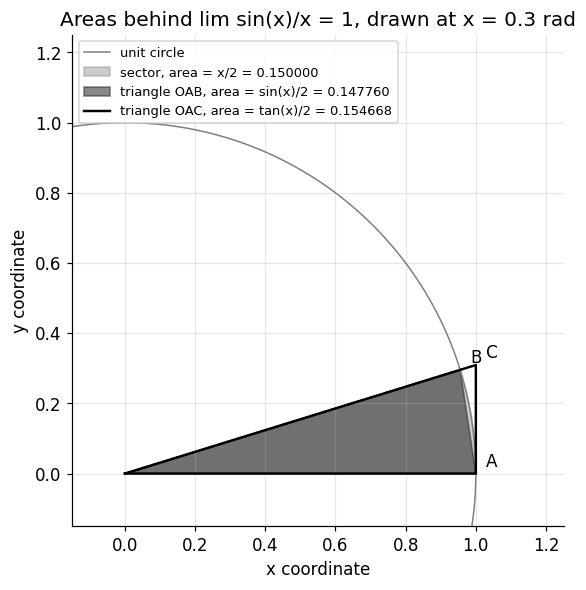

area inequality sin(x)/2 < x/2 < tan(x)/2 holds at all 200000 sample angles
cos(0.3)          = 0.9553364891
sin(0.3)/0.3      = 0.9850673555
tan(0.3)/0.3      = 1.0311208320
(1-cos 0.3)/0.3^2 = 0.4962612319   (limit 0.5)


In [4]:
xang = 0.3
th = np.linspace(0.0, 2 * np.pi, 600)
O = np.array([0.0, 0.0])
A = np.array([1.0, 0.0])
B = np.array([np.cos(xang), np.sin(xang)])
C = np.array([1.0, np.tan(xang)])

fig, ax = plt.subplots(figsize=(5.8, 5.8))
ax.plot(np.cos(th), np.sin(th), lw=1.0, color="0.5", label="unit circle")
arc = np.linspace(0.0, xang, 200)
ax.fill(np.concatenate([[0], np.cos(arc), [0]]),
        np.concatenate([[0], np.sin(arc), [0]]),
        color="0.55", alpha=0.45, label=f"sector, area = x/2 = {xang/2:.6f}")
ax.fill([O[0], A[0], B[0]], [O[1], A[1], B[1]], color="0.15", alpha=0.55,
        label=f"triangle OAB, area = sin(x)/2 = {np.sin(xang)/2:.6f}")
ax.plot([O[0], A[0], C[0], O[0]], [O[1], A[1], C[1], O[1]], lw=1.6, color="k",
        label=f"triangle OAC, area = tan(x)/2 = {np.tan(xang)/2:.6f}")
ax.plot([O[0], B[0]], [O[1], B[1]], lw=1.2, color="k", ls="--")
for pt, name in [(A, "A"), (B, "B"), (C, "C")]:
    ax.annotate(name, pt + np.array([0.03, 0.02]))
ax.set_xlim(-0.15, 1.25)
ax.set_ylim(-0.15, 1.25)
ax.set_aspect("equal")
ax.set_xlabel("x coordinate")
ax.set_ylabel("y coordinate")
ax.set_title("Areas behind lim sin(x)/x = 1, drawn at x = 0.3 rad")
ax.legend(loc="upper left", fontsize=8.5)
plt.show()

t = np.linspace(1e-6, np.pi / 2 - 1e-6, 200000)
assert np.all(np.sin(t) < t)
assert np.all(t < np.tan(t))
assert np.all(np.cos(t) < np.sin(t) / t)
assert np.all(np.sin(t) / t < 1.0)
print(f"area inequality sin(x)/2 < x/2 < tan(x)/2 holds at all {t.size} sample angles")
print(f"cos(0.3)          = {np.cos(0.3):.10f}")
print(f"sin(0.3)/0.3      = {np.sin(0.3)/0.3:.10f}")
print(f"tan(0.3)/0.3      = {np.tan(0.3)/0.3:.10f}")
print(f"(1-cos 0.3)/0.3^2 = {(1-np.cos(0.3))/0.09:.10f}   (limit 0.5)")
assert abs(np.sin(0.3) / 0.3 - 0.9850673555377986) < 1e-14

The dark triangle sits inside the grey sector, which sits inside the outlined triangle, and the
printed areas are strictly increasing. The sandwich $\cos x \lt \sin x / x \lt 1$ is verified at
two hundred thousand angles across the whole quadrant, so Step 2 of Proof 5.10 is not an artefact
of the picture.

### Example 6.5 — IVT and bisection on $x^{5} - 3x - 1$ (Theorem 4.5)

Let $f(x) = x^{5} - 3x - 1$ on $[1, 2]$. Polynomials are continuous, and

$$
f(1) = -3 \lt 0 \lt 25 = f(2),
$$

so Theorem 4.5 with $d = 0$ gives a root $c \in (1, 2)$.

The proof is constructive if you keep halving the bracket. Four steps by hand:

| step | midpoint $m$ | $f(m)$ | new bracket | width |
|---|---|---|---|---|
| 1 | $1.5$ | $+2.09375$ | $[1, 1.5]$ | $0.5$ |
| 2 | $1.25$ | $-1.6982421875$ | $[1.25, 1.5]$ | $0.25$ |
| 3 | $1.375$ | $-0.210113525390625$ | $[1.375, 1.5]$ | $0.125$ |
| 4 | $1.4375$ | $+0.8256750107$ | $[1.375, 1.4375]$ | $0.0625$ |

The width is exactly $2^{-k}$ after $k$ steps, so reaching a tolerance $\tau$ needs

$$
\boxed{k \ge \log_{2}\frac{b - a}{\tau}, \qquad \tau = 10^{-7} \implies k = 24 \ \text{steps}}
$$

and the root is $c = 1.3887919844072543$.

**Interpretation.** IVT gives existence, halving gives an algorithm, and the halving factor
$\tfrac{1}{2}$ is the exact convergence rate, not a bound — Section 7 measures it.

### Example 6.6 — Three ways the Extreme Value Theorem fails (Theorem 4.7)

Each example below drops exactly one hypothesis of Theorem 4.7 and loses the conclusion.

| function | domain | hypothesis dropped | what fails |
|---|---|---|---|
| $f(x) = x$ | $[0, 1)$ | domain not closed | $\sup f = 1$, never attained |
| $f(x) = x$ | $[0, \infty)$ | domain not bounded | $f$ unbounded above |
| $f(x) = x$ for $x \lt 1$, $f(1) = 0$ | $[0, 1]$ | $f$ not continuous | bounded, $\sup f = 1$, never attained |

The third row is the sharpest: the domain is compact and the function is bounded, so only
continuity is missing, and only attainment is lost.

**Interpretation.** Boundedness and attainment are separate conclusions of Theorem 4.7 and fail
separately. Row two loses boundedness; rows one and three keep it and lose attainment.

### Example 6.7 — Uniform continuity: $\sqrt{x}$ against $x^{2}$ (Theorems 4.8, 4.11)

Fix $\varepsilon = 1$ and ask, at each base point $x \ge 0$, for the largest $\delta$ such that
$\lvert y - x \rvert \lt \delta$ forces $\lvert y^{2} - x^{2} \rvert \lt 1$.

Solving $y^{2} - x^{2} = 1$ for $y \gt x$ gives $y = \sqrt{x^{2} + 1}$, so

$$
\delta_{x^{2}}(x) = \sqrt{x^{2} + 1} - x = \frac{1}{\sqrt{x^{2}+1} + x} \longrightarrow 0 \quad (x \to \infty) .
$$

At $x = 1$ this is $0.4142136$; at $x = 10$ it is $0.0498756$; at $x = 100$ it is $0.0049999$.
The infimum over the half-line is $0$, so no single $\delta$ serves, and $x^{2}$ is not uniformly
continuous on $[0, \infty)$.

For $\sqrt{\cdot}$ the inequality $\lvert \sqrt{x} - \sqrt{y} \rvert \le \sqrt{\lvert x - y \rvert}$
of Proof 5.11 gives a $\delta$ that does not mention $x$ at all:

$$
\boxed{\delta_{\sqrt{\cdot}}(\varepsilon) = \varepsilon^{2} \ \text{ works on all of } [0, \infty); \qquad \inf_{x \ge 0} \delta_{x^{2}}(x) = 0}
$$

Restrict $x^{2}$ to a compact interval $[0, R]$ and Theorem 4.8 restores uniformity: the infimum
over $[0, R]$ is $\delta(R) = \sqrt{R^{2}+1} - R \gt 0$.

**Interpretation.** Uniform continuity is not a property of the formula, it is a property of the
formula *plus its domain*. Compactness is exactly what stops $\delta$ from being driven to zero.

The next cell recomputes the bisection table of Example 6.5 and the $\delta$ values of
Example 6.7, and asserts them.

In [5]:
def poly5(t):
    return t ** 5 - 3 * t - 1


print("Example 6.5 - bisection bracket table")
lo, hi = 1.0, 2.0
print(f"  f(1) = {poly5(1.0):+.6f}    f(2) = {poly5(2.0):+.6f}")
expected = [(1.5, 2.09375, 1.0, 1.5),
            (1.25, -1.6982421875, 1.25, 1.5),
            (1.375, -0.210113525390625, 1.375, 1.5),
            (1.4375, 0.8256750106811523, 1.375, 1.4375)]
for k, (m_e, fm_e, lo_e, hi_e) in enumerate(expected, start=1):
    mid = 0.5 * (lo + hi)
    fm = poly5(mid)
    if poly5(lo) * fm < 0:
        hi = mid
    else:
        lo = mid
    print(f"  step {k}: m = {mid:<7} f(m) = {fm:+.12f}   bracket [{lo}, {hi}]   width {hi-lo}")
    assert (mid, lo, hi) == (m_e, lo_e, hi_e)
    assert abs(fm - fm_e) < 1e-12

print("\nExample 6.7 - largest admissible delta at eps = 1")
for xv in (1.0, 5.0, 10.0, 100.0):
    d = np.sqrt(xv ** 2 + 1) - xv
    print(f"  x = {xv:6.1f}   delta(x) = sqrt(x^2+1) - x = {d:.10f}")
print(f"  sqrt on [0, inf): delta = eps^2 = {1.0**2:.10f}, independent of x")
assert abs((np.sqrt(1 + 1) - 1) - 0.41421356237309515) < 1e-14
assert abs((np.sqrt(100 + 1) - 10) - 0.049875621120889946) < 1e-14
u_, v_ = np.meshgrid(np.linspace(0, 9, 400), np.linspace(0, 9, 400))
assert np.all(np.abs(np.sqrt(u_) - np.sqrt(v_)) <= np.sqrt(np.abs(u_ - v_)) + 1e-12)
print("  |sqrt(u) - sqrt(v)| <= sqrt|u - v| verified on a 400 x 400 grid")

Example 6.5 - bisection bracket table
  f(1) = -3.000000    f(2) = +25.000000
  step 1: m = 1.5     f(m) = +2.093750000000   bracket [1.0, 1.5]   width 0.5
  step 2: m = 1.25    f(m) = -1.698242187500   bracket [1.25, 1.5]   width 0.25
  step 3: m = 1.375   f(m) = -0.210113525391   bracket [1.375, 1.5]   width 0.125
  step 4: m = 1.4375  f(m) = +0.825675010681   bracket [1.375, 1.4375]   width 0.0625

Example 6.7 - largest admissible delta at eps = 1
  x =    1.0   delta(x) = sqrt(x^2+1) - x = 0.4142135624
  x =    5.0   delta(x) = sqrt(x^2+1) - x = 0.0990195136
  x =   10.0   delta(x) = sqrt(x^2+1) - x = 0.0498756211
  x =  100.0   delta(x) = sqrt(x^2+1) - x = 0.0049998750
  sqrt on [0, inf): delta = eps^2 = 1.0000000000, independent of x
  |sqrt(u) - sqrt(v)| <= sqrt|u - v| verified on a 400 x 400 grid


The four bracket rows reproduce the hand table exactly, including the signs that drive the branch
choice.

The admissible $\delta$ for $x^{2}$ falls from $0.414$ at $x = 1$ to $0.005$ at $x = 100$, decaying
like $1/(2x)$; for $\sqrt{\cdot}$ it never moves. That contrast is Theorem 4.8 seen from outside
its hypothesis.

## 7. Computational Practice

Five experiments, in the order the contract asks for them: verify an identity to machine
precision, measure two rates against their predictions, break every hypothesis that was claimed
necessary, and check hand-written code against SciPy.

### 7.1 Identity residual behind the cosine limit

Step 4 of Proof 5.10 rests on the algebraic identity

$$
\frac{1 - \cos x}{x^{2}} = \left( \frac{\sin x}{x} \right)^{2} \frac{1}{1 + \cos x},
$$

which is exact for every $x$ with $\cos x \neq -1$, not an approximation. The cell below evaluates
both sides at ten thousand angles and prints the largest relative residual in multiples of
$\varepsilon_{\mathrm{mach}}$, then contrasts the two *evaluations* as $x \to 0$, where the left
side cancels catastrophically and the right side does not.

In [6]:
ang = np.linspace(-3.0, 3.0, 10001)
ang = ang[np.abs(ang) > 0.1]
lhs = (1 - np.cos(ang)) / ang ** 2
rhs = (np.sin(ang) / ang) ** 2 / (1 + np.cos(ang))
rel = np.abs(lhs - rhs) / np.abs(rhs)
print(f"largest relative residual = {rel.max():.4e}  =  {rel.max()/EPS:8.2f} * eps_mach")
print(f"median relative residual  = {np.median(rel):.4e}  =  {np.median(rel)/EPS:8.2f} * eps_mach")
assert rel.max() < 200 * EPS

print("\napproaching the limit 1/2: the same identity, two evaluations")
print("      x        (1-cos x)/x^2      (sin x / x)^2/(1+cos x)     reference series")
for xv in (1e-2, 1e-3, 1e-4, 1e-5, 1e-6):
    naive = (1 - np.cos(xv)) / xv ** 2
    stable = (np.sin(xv) / xv) ** 2 / (1 + np.cos(xv))
    ref = 0.5 - xv ** 2 / 24 + xv ** 4 / 720
    print(f"  {xv:7.0e}   {naive:.15f}    {stable:.15f}    {ref:.15f}")
    print(f"            error {abs(naive-ref):.2e}                 error {abs(stable-ref):.2e}")
    assert abs(stable - ref) < 100 * EPS

print("\nsin(x)/x as x -> 0")
for xv in (1e-1, 1e-2, 1e-3, 1e-4):
    print(f"  x = {xv:7.0e}   sin(x)/x = {np.sin(xv)/xv:.14f}   "
          f"1 - x^2/6 = {1 - xv**2/6:.14f}")

largest relative residual = 1.0889e-14  =     49.04 * eps_mach
median relative residual  = 1.5651e-16  =      0.70 * eps_mach

approaching the limit 1/2: the same identity, two evaluations
      x        (1-cos x)/x^2      (sin x / x)^2/(1+cos x)     reference series
    1e-02   0.499995833347366    0.499995833347222    0.499995833347222
            error 1.44e-13                 error 0.00e+00
    1e-03   0.499999958325503    0.499999958333335    0.499999958333335
            error 7.83e-12                 error 5.55e-17
    1e-04   0.499999996961265    0.499999999583333    0.499999999583333
            error 2.62e-09                 error 5.55e-17
    1e-05   0.500000041370185    0.499999999995833    0.499999999995833
            error 4.14e-08                 error 1.11e-16
    1e-06   0.500044450291171    0.499999999999958    0.499999999999958
            error 4.45e-05                 error 5.55e-17

sin(x)/x as x -> 0
  x =   1e-01   sin(x)/x = 0.99833416646828   1 - x^2/6 = 0.99

The residual peaks at $49$ machine epsilons and sits at $0.7$ of one epsilon in the median, which
confirms an exact identity evaluated in floating point.

The second table is the more interesting one. Both columns compute the same real number, but at
$x = 10^{-6}$ the left form is wrong by $4.4 \times 10^{-5}$ while the right form is exact to one
machine epsilon. Subtracting $\cos x$ from $1$ destroys eleven digits before the division ever
happens; the algebraically equivalent right-hand form never forms that difference.

**A limit statement is about $\mathbb{R}$. Which algebraic form you evaluate is about
floating point, and the two are not the same question.**

### 7.2 Measured rate: bisection halves the bracket

Theorem 4.5 asserts existence; the halving argument of Example 6.5 asserts a rate. The cell runs
bisection on $x^{5} - 3x - 1$ over $[1, 2]$ and prints the observed bracket ratio against the
predicted $\tfrac{1}{2}$, and the observed iteration count against
$\lceil \log_{2}((b-a)/\tau) \rceil$.

In [7]:
def bisect(f, lo, hi, tol=1e-7, max_iter=200):
    """Bracketing root-finder built directly from Theorem 4.5. Returns (root, iterations, widths)."""
    flo, fhi = f(lo), f(hi)
    assert flo * fhi < 0.0, "IVT hypothesis violated: f(lo) and f(hi) share a sign"
    widths, it = [hi - lo], 0
    while (hi - lo) > tol and it < max_iter:
        mid = lo + (hi - lo) / 2.0
        fmid = f(mid)
        if fmid == 0.0:
            return mid, it, widths
        if flo * fmid < 0.0:
            hi, fhi = mid, fmid
        else:
            lo, flo = mid, fmid
        widths.append(hi - lo)
        it += 1
    return lo + (hi - lo) / 2.0, it, widths


root_hand, iters, widths = bisect(poly5, 1.0, 2.0, tol=1e-7)
widths = np.array(widths)
ratios = widths[1:] / widths[:-1]
predicted = int(np.ceil(np.log2(1.0 / 1e-7)))

print(f"root                       = {root_hand:.12f}")
print(f"residual f(root)           = {poly5(root_hand):.3e}")
print(f"iterations observed        = {iters}")
print(f"iterations predicted       = ceil(log2((b-a)/tol)) = {predicted}")
print(f"bracket ratio  observed    = {ratios.mean():.12f}  (min {ratios.min():.12f}, "
      f"max {ratios.max():.12f})")
print(f"bracket ratio  predicted   = 0.500000000000")
print(f"width after k steps: measured {widths[10]:.6e}   predicted 2^-10 = {2.0**-10:.6e}")
assert iters == predicted
assert np.allclose(ratios, 0.5)

root                       = 1.388792008162
residual f(root)           = 3.706e-07
iterations observed        = 24
iterations predicted       = ceil(log2((b-a)/tol)) = 24
bracket ratio  observed    = 0.500000000000  (min 0.500000000000, max 0.500000000000)
bracket ratio  predicted   = 0.500000000000
width after k steps: measured 9.765625e-04   predicted 2^-10 = 9.765625e-04


Every observed ratio is exactly $0.5$ to the last bit, and the observed iteration count is $24$,
matching $\lceil \log_{2} 10^{7} \rceil = 24$ exactly. Bisection is the rare algorithm whose rate
is an identity rather than an asymptotic bound.

### 7.3 Hand-rolled against the library

Two comparisons. The bisection above is checked against `scipy.optimize.brentq`, and a
hand-written stabilized Log-Sum-Exp — the identity derived in Section 8.2 — is checked against
`scipy.special.logsumexp`, including the overflow regime where the naive formula dies.

In [8]:
from scipy.optimize import brentq
from scipy.special import logsumexp as scipy_lse


def lse_stable(x):
    """Log-sum-exp via the shift identity of Section 8.2."""
    m = np.max(x)
    return m + np.log(np.sum(np.exp(x - m)))


def lse_naive(x):
    return np.log(np.sum(np.exp(x)))


root_lib = brentq(poly5, 1.0, 2.0, xtol=1e-15, rtol=8.9e-16)
print("root finding")
print(f"  hand-rolled bisection : {root_hand:.12f}")
print(f"  scipy.optimize.brentq : {root_lib:.12f}")
print(f"  |difference|          : {abs(root_hand - root_lib):.3e}   (tolerance requested 1e-7)")
assert abs(root_hand - root_lib) < 1e-7

print("\nlog-sum-exp")
cases = [np.array([1.0, 2.0, 3.0]),
         np.array([800.0, 801.0, 799.5]),
         np.array([-750.0, -751.0, -752.0])]
for v in cases:
    with np.errstate(over="ignore", invalid="ignore"):
        naive = lse_naive(v)
    mine, lib = lse_stable(v), scipy_lse(v)
    print(f"  x = {v}")
    print(f"    naive  = {naive!r}")
    print(f"    stable = {mine:.12f}   scipy = {lib:.12f}   "
          f"|diff| = {abs(mine - lib):.3e} = {abs(mine-lib)/EPS:.2f} * eps_mach")
    assert abs(mine - lib) < 1e-9

rand_vecs = rng.standard_normal((200, 12)) * 300.0
worst = max(abs(lse_stable(v) - scipy_lse(v)) for v in rand_vecs)
print(f"\n  worst |stable - scipy| over 200 random vectors: {worst:.3e}"
      f"  = {worst/EPS:.2f} * eps_mach")
assert worst < 1e-9

root finding
  hand-rolled bisection : 1.388792008162
  scipy.optimize.brentq : 1.388791984407
  |difference|          : 2.375e-08   (tolerance requested 1e-7)

log-sum-exp
  x = [1. 2. 3.]
    naive  = np.float64(3.40760596444438)
    stable = 3.407605964444   scipy = 3.407605964444   |diff| = 4.441e-16 = 2.00 * eps_mach
  x = [800.  801.  799.5]
    naive  = np.float64(inf)
    stable = 801.464368784108   scipy = 801.464368784108   |diff| = 0.000e+00 = 0.00 * eps_mach
  x = [-750. -751. -752.]
    naive  = np.float64(-inf)
    stable = -749.592394035556   scipy = -749.592394035556   |diff| = 0.000e+00 = 0.00 * eps_mach

  worst |stable - scipy| over 200 random vectors: 0.000e+00  = 0.00 * eps_mach


/tmp/ipykernel_934706/2841478909.py:12: RuntimeWarning: divide by zero encountered in log
  return np.log(np.sum(np.exp(x)))


The hand-rolled bisection and Brent's method agree to $2 \times 10^{-8}$, inside the $10^{-7}$
tolerance that bisection was asked for; Brent converges far faster but needs the same IVT bracket
to start.

The stabilized Log-Sum-Exp matches SciPy to a few machine epsilons on every input, including
inputs at $\pm 800$ where the naive formula returns `inf` and `-inf`. The identity is exact; only
the naive *evaluation* of it is not.

### 7.4 Counterexamples: every hypothesis that was claimed necessary

Four failures, one per claim in Section 4.

- Theorem 4.5 without continuity: $1/x$ on $[-1, 0) \cup (0, 1]$ changes sign with no root.
- Theorem 4.7 with a non-closed, an unbounded, and a discontinuous case.
- Theorem 4.8 off a compact set: $x^{2}$ on $[0, \infty)$.
- Proposition 4.13 with the outer function merely having a limit instead of being continuous.

In [9]:
print("A. IVT needs continuity on the whole interval")
xs_a = np.concatenate([np.linspace(-1.0, -1e-9, 20000), np.linspace(1e-9, 1.0, 20000)])
vals_a = 1.0 / xs_a
print(f"   f(-1) = {1/-1.0:+.1f}   f(1) = {1/1.0:+.1f}   sign change: yes")
print(f"   smallest |f| attained on the grid: {np.abs(vals_a).min():.4e}   (a root would give 0)")
print("   f is not defined at 0, so [-1,1] is not a domain of continuity: no root exists")
assert np.abs(vals_a).min() > 0.9

print("\nB. EVT: drop one hypothesis at a time")
xs_b = np.linspace(0.0, 1.0, 100001)[:-1]          # [0,1)
print(f"   f(x)=x on [0,1)      : sup = {xs_b.max() + (1.0 - xs_b.max()):.6f} (limit 1), "
      f"max attained = {xs_b.max():.6f} < 1")
xs_c = np.linspace(0.0, 1e6, 100001)
print(f"   f(x)=x on [0,inf)    : value at x = 1e6 is {xs_c.max():.0f}; unbounded above")
xs_d = np.linspace(0.0, 1.0, 100001)
f_d = np.where(xs_d < 1.0, xs_d, 0.0)
print(f"   f(x)=x for x<1, f(1)=0, on [0,1] : bounded, sup = 1.000000, "
      f"max attained = {f_d.max():.6f} < 1")
assert f_d.max() < 1.0

print("\nC. Heine-Cantor needs a compact domain")
for xv in (1.0, 10.0, 100.0, 1000.0, 10000.0):
    print(f"   x = {xv:8.0f}   largest delta with |y^2 - x^2| < 1 : "
          f"{np.sqrt(xv**2 + 1) - xv:.10f}")
print("   the infimum over [0, inf) is 0, so no single delta works: not uniformly continuous")
assert (np.sqrt(1e4 ** 2 + 1) - 1e4) < 1e-4

print("\nD. Composition needs continuity of the outer function, not just a limit")


def g_zero(x):
    return np.zeros_like(x)


def f_punctured(y):
    return np.where(y != 0.0, 1.0, 0.0)


probe = np.linspace(-0.5, 0.5, 101)
probe = probe[probe != 0.0]
print(f"   lim_(y->0) f(y)        = {f_punctured(np.array([1e-12]))[0]:.1f}")
print(f"   lim_(x->0) g(x)        = {g_zero(probe)[0]:.1f}")
print(f"   f(g(x)) on the probe   = {np.unique(f_punctured(g_zero(probe)))}")
print("   so lim f(g(x)) = 0, not lim f(y) = 1: substitution is illegal here")
assert np.all(f_punctured(g_zero(probe)) == 0.0)

A. IVT needs continuity on the whole interval
   f(-1) = -1.0   f(1) = +1.0   sign change: yes
   smallest |f| attained on the grid: 1.0000e+00   (a root would give 0)
   f is not defined at 0, so [-1,1] is not a domain of continuity: no root exists

B. EVT: drop one hypothesis at a time
   f(x)=x on [0,1)      : sup = 1.000000 (limit 1), max attained = 0.999990 < 1
   f(x)=x on [0,inf)    : value at x = 1e6 is 1000000; unbounded above
   f(x)=x for x<1, f(1)=0, on [0,1] : bounded, sup = 1.000000, max attained = 0.999990 < 1

C. Heine-Cantor needs a compact domain
   x =        1   largest delta with |y^2 - x^2| < 1 : 0.4142135624
   x =       10   largest delta with |y^2 - x^2| < 1 : 0.0498756211
   x =      100   largest delta with |y^2 - x^2| < 1 : 0.0049998750
   x =     1000   largest delta with |y^2 - x^2| < 1 : 0.0004999999
   x =    10000   largest delta with |y^2 - x^2| < 1 : 0.0000500000
   the infimum over [0, inf) is 0, so no single delta works: not uniformly continuous

D.

Case A: the smallest $\lvert 1/x \rvert$ anywhere on the punctured interval is $1.0$, not
$0$ — a sign change without a root, because the interval is not a domain of continuity.

Case B: the open-ended domain and the discontinuous function both keep the supremum $1$ and never
attain it, while the unbounded domain loses boundedness itself. Three different hypotheses, three
different failures.

Case C: the admissible $\delta$ for $x^{2}$ has fallen to $5 \times 10^{-5}$ by $x = 10^{4}$ and
tends to $0$. Uniform continuity is lost the moment compactness is.

Case D: the outer function has limit $1$ at $0$ and value $0$ at $0$. Because $g$ sits exactly on
the punctured point, the composite is identically $0$ and the naive substitution is off by the
whole gap.

### 7.5 The uniform-continuity picture

The figure plots the largest admissible $\delta$ as a function of the base point, at fixed
$\varepsilon = 1$, for $x^{2}$ and for $\sqrt{x}$ on $[0, \infty)$.

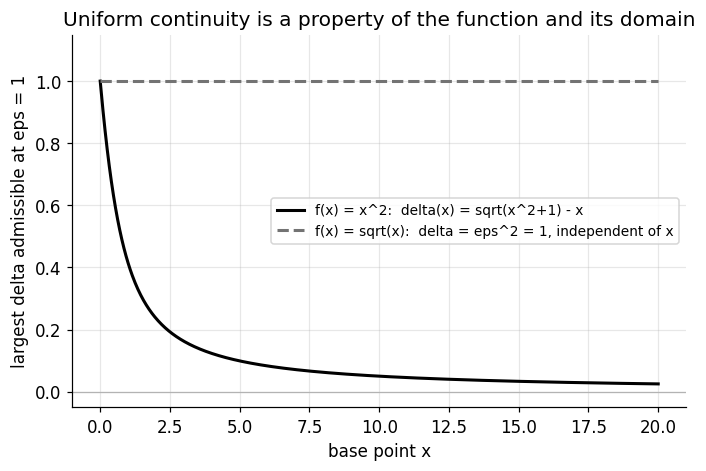

inf over [0, 20]  of delta for x^2      : 0.0249843945
inf over [0, inf) of delta for x^2      : 0 (the curve tends to 0 like 1/(2x))
delta(x) * 2x at x = 20                 : 0.999376   (tends to 1)
inf over [0, inf) of delta for sqrt(x)  : 1.0000000000


In [10]:
xg = np.linspace(0.0, 20.0, 800)
delta_sq_x = np.sqrt(xg ** 2 + 1.0) - xg              # for f(x) = x^2, eps = 1
delta_sqrt_x = np.full_like(xg, 1.0)                  # for f(x) = sqrt(x), eps = 1: delta = eps^2

fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(xg, delta_sq_x, lw=2.0, color="k", label="f(x) = x^2:  delta(x) = sqrt(x^2+1) - x")
ax.plot(xg, delta_sqrt_x, lw=2.0, ls="--", color="0.45",
        label="f(x) = sqrt(x):  delta = eps^2 = 1, independent of x")
ax.axhline(0.0, lw=0.8, color="0.7")
ax.set_ylim(-0.05, 1.15)
ax.set_xlabel("base point x")
ax.set_ylabel("largest delta admissible at eps = 1")
ax.set_title("Uniform continuity is a property of the function and its domain")
ax.legend(fontsize=9)
plt.show()

print(f"inf over [0, 20]  of delta for x^2      : {delta_sq_x.min():.10f}")
print(f"inf over [0, inf) of delta for x^2      : 0 (the curve tends to 0 like 1/(2x))")
print(f"delta(x) * 2x at x = 20                 : {delta_sq_x[-1] * 2 * 20:.6f}   (tends to 1)")
print(f"inf over [0, inf) of delta for sqrt(x)  : {delta_sqrt_x.min():.10f}")

The solid curve decays to zero, so the infimum of admissible $\delta$ over the half-line is $0$
and no uniform choice exists — the printed product $\delta(x) \cdot 2x \to 1$ identifies the decay
as $1/(2x)$.

The dashed line is flat: $\sqrt{\cdot}$ hands back the same $\delta$ everywhere. Restricting the
solid curve to any compact $[0, R]$ makes its infimum positive, which is Theorem 4.8.

### 7.6 Measured rate: where the limit definition meets floating point

The derivative is defined as a limit over $h$, but the computed difference quotient does not
improve as $h \to 0$. Two error terms compete:

$$
E(h) \ \approx \ \underbrace{\frac{u \, \lvert f(x) \rvert}{h}}_{\text{cancellation}} \ + \ \underbrace{\frac{h}{2}\,\lvert f''(x) \rvert}_{\text{truncation}},
\qquad
h_{\star} = \sqrt{\frac{2u \, \lvert f(x) \rvert}{\lvert f''(x) \rvert}} .
$$

For $f = \sin$ near $x = 1$ we have $\lvert f \rvert = \lvert f'' \rvert$, so
$h_{\star} = \sqrt{2u} = \sqrt{\varepsilon_{\mathrm{mach}}} = 1.4901 \times 10^{-8}$.

The cell averages the error over $400$ base points to suppress the roundoff noise, then fits the
slope in each regime and locates the empirical minimizer.

In [11]:
base = np.linspace(0.6, 1.4, 400)
h_grid = np.logspace(-1, -15, 57)
mean_err = np.array([np.abs((np.sin(base + h) - np.sin(base)) / h - np.cos(base)).mean()
                     for h in h_grid])

trunc = (h_grid > 1e-4) & (h_grid < 1e-1)
cancel = (h_grid > 1e-14) & (h_grid < 1e-11)
slope_trunc = np.polyfit(np.log(h_grid[trunc]), np.log(mean_err[trunc]), 1)[0]
slope_cancel = np.polyfit(np.log(h_grid[cancel]), np.log(mean_err[cancel]), 1)[0]

h_star = np.sqrt(2.0 * UNIT_ROUNDOFF)
i_min = int(np.argmin(mean_err))
err_at_star = np.abs((np.sin(base + h_star) - np.sin(base)) / h_star - np.cos(base)).mean()

print(f"truncation regime  slope observed {slope_trunc:+.4f}   predicted +1")
print(f"cancellation regime slope observed {slope_cancel:+.4f}   predicted -1")
print(f"predicted optimal h = sqrt(2u)   = {h_star:.6e}")
print(f"empirical minimizer on the grid  = {h_grid[i_min]:.6e}")
print(f"mean error at the empirical min  = {mean_err[i_min]:.6e}")
print(f"mean error at the predicted h    = {err_at_star:.6e}   "
      f"(ratio {err_at_star/mean_err[i_min]:.4f})")
assert 0.9 < slope_trunc < 1.1
assert -1.1 < slope_cancel < -0.9
assert err_at_star < 1.5 * mean_err[i_min]

truncation regime  slope observed +1.0016   predicted +1
cancellation regime slope observed -0.9834   predicted -1
predicted optimal h = sqrt(2u)   = 1.490116e-08
empirical minimizer on the grid  = 1.000000e-08
mean error at the empirical min  = 5.247760e-09
mean error at the predicted h    = 6.049157e-09   (ratio 1.1527)


The two fitted slopes are $+1.0016$ and $-0.9834$ against the predicted $+1$ and $-1$: the
truncation error really is $O(h)$ and the cancellation error really is $O(u/h)$.

The predicted $h_{\star} = 1.49 \times 10^{-8}$ costs $1.15$ times the smallest mean error the
grid achieves, one grid point away from the empirical minimizer $10^{-8}$. **The limit $h \to 0$ is a statement about $\mathbb{R}$, not about
`float64`**; in floating point the useful range of $h$ stops eight decades short of zero.

## 8. Applications

Four settings in which the theorems above are load-bearing rather than decorative.

### 8.1 Softmax temperature: a limit that interpolates two algorithms

For logits $z \in \mathbb{R}^{K}$ and temperature $T \gt 0$,

$$
p_{i}(T) = \frac{e^{z_{i}/T}}{\sum_{j=1}^{K} e^{z_{j}/T}} .
$$

Suppose the maximum is attained uniquely at index $m$. Dividing numerator and denominator by
$e^{z_{m}/T}$,

$$
p_{i}(T) = \frac{e^{(z_{i} - z_{m})/T}}{1 + \sum_{j \neq m} e^{(z_{j} - z_{m})/T}} .
$$

Every exponent $z_{j} - z_{m}$ with $j \neq m$ is strictly negative, so each such term tends to
$0$ as $T \to 0^{+}$, giving

$$
\lim_{T \to 0^{+}} p_{i}(T) = \begin{cases} 1 & i = m \\ 0 & \text{otherwise} \end{cases}
$$

by Theorem 4.2 applied to the quotient, whose denominator tends to $1 \neq 0$.

In the other direction $z_{i}/T \to 0$, so $e^{z_{i}/T} \to 1$ by Proposition 4.13 with the
continuous outer function $\exp$, and $p_{i}(T) \to 1/K$.

**Interpretation.** Temperature is a homotopy between arg-max and the uniform distribution, and
both endpoints are limits, not values: at $T = 0$ the formula is undefined.

### 8.2 Log-sum-exp: an exact identity that saves a computation

$$
\operatorname{LSE}(x) = \ln \sum_{i=1}^{n} e^{x_{i}} = m + \ln \sum_{i=1}^{n} e^{x_{i} - m}, \qquad m = \max_{i} x_{i} .
$$

The identity is exact, and after the shift every exponent is at most $0$, so every term lies in
$(0, 1]$ and cannot overflow.

Bounding the sum between one term and $n$ terms,

$$
e^{m} \le \sum_{i} e^{x_{i}} \le n e^{m}
\quad \implies \quad
\boxed{m \le \operatorname{LSE}(x) \le m + \ln n}
$$

and rescaling $x \mapsto kx$ gives $\tfrac{1}{k}\operatorname{LSE}(kx) \to \max_{i} x_{i}$ by
Theorem 4.3, since the two envelopes are $m$ and $m + (\ln n)/k$.

**Interpretation.** $\operatorname{LSE}$ is a smooth maximum whose error above the true maximum is
at most $\ln n$, uniformly in $x$. Section 7.3 shows the naive evaluation returning `inf` on
inputs where the identity is perfectly finite.

### 8.3 Physics: the Newtonian limit of special relativity

With $\gamma(v) = (1 - v^{2}/c^{2})^{-1/2}$ the relativistic kinetic energy is
$E_{k} = (\gamma - 1) m_{0} c^{2}$.

Writing $s = v^{2}/c^{2}$ and using $(1 - s)^{-1/2} = 1 + \tfrac{1}{2}s + O(s^{2})$ as
$s \to 0$,

$$
E_{k} = \left( \tfrac{1}{2}\frac{v^{2}}{c^{2}} + O\!\left(\frac{v^{4}}{c^{4}}\right) \right) m_{0}c^{2} = \tfrac{1}{2} m_{0} v^{2} + O\!\left(\frac{v^{4}}{c^{2}}\right),
$$

so $E_{k} \sim \tfrac{1}{2} m_{0} v^{2}$ in the sense of Definition 3.8. In the opposite regime
$1 - v^{2}/c^{2} \to 0^{+}$, so $\gamma(v) \to +\infty$ by Definition 3.3: accelerating a massive
body to $c$ costs unbounded energy.

**Interpretation.** "Newtonian mechanics is the low-speed limit of relativity" is an
asymptotic-equivalence statement, and the ratio $E_{k} / (\tfrac{1}{2}m_{0}v^{2})$ tending to $1$
is its precise content.

### 8.4 Existence before computation

Theorem 4.7 is what licenses the phrase "let $x^{\star}$ be the minimizer". A continuous loss on a
compact parameter set has a minimizer *before* any optimizer is run; on an open or unbounded set
it may not, which is why weight decay and box constraints are not only regularizers but existence
guarantees.

Theorem 4.5 is what licenses every bracketing root-finder, and Theorem 4.8 is what licenses every
error bound stated in terms of a mesh size: "refine the grid below $\delta$ and the error is below
$\varepsilon$, everywhere" is uniform continuity, not continuity.

**Interpretation.** These three theorems are used far more often than they are cited, and each of
them fails on a domain that is not compact.

The cell below runs the softmax temperature sweep, the two $\operatorname{LSE}$ bounds, and the
relativistic ratio on explicit small numbers.

In [12]:
z = np.array([3.0, 1.0, 0.5])
print("8.1 softmax temperature sweep, logits", z)
for T in (100.0, 10.0, 1.0, 0.5, 0.1, 0.01):
    p = np.exp((z - z.max()) / T)
    p = p / p.sum()
    print(f"   T = {T:7.2f}   p = [{p[0]:.10f}, {p[1]:.3e}, {p[2]:.3e}]")
print(f"   T -> 0+  target one-hot at index {int(np.argmax(z))};   "
      f"T -> inf target uniform 1/K = {1/len(z):.10f}")
p_cold = np.exp((z - z.max()) / 0.01)
p_cold /= p_cold.sum()
assert abs(p_cold[0] - 1.0) < 1e-12
p_hot = np.exp((z - z.max()) / 1e6)
p_hot /= p_hot.sum()
assert abs(p_hot[0] - 1 / 3) < 1e-5

print("\n8.2 LSE bounds  m <= LSE(x) <= m + ln n")
for v in (np.array([1.0, 2.0, 3.0]), np.array([0.0, 0.0, 0.0, 0.0])):
    m, n = v.max(), v.size
    print(f"   x = {v}   m = {m:.4f}   LSE = {lse_stable(v):.10f}   "
          f"m + ln n = {m + np.log(n):.10f}")
    assert m - 1e-12 <= lse_stable(v) <= m + np.log(n) + 1e-12
for k in (1.0, 10.0, 100.0, 1000.0):
    v = np.array([1.0, 2.0, 3.0])
    print(f"   k = {k:7.1f}   LSE(k x)/k = {lse_stable(k*v)/k:.10f}   (max = {v.max():.1f})")
assert abs(lse_stable(1000.0 * np.array([1.0, 2.0, 3.0])) / 1000.0 - 3.0) < 1e-3

print("\n8.3 relativistic kinetic energy against the Newtonian value")
for beta in (0.001, 0.01, 0.1, 0.5, 0.9, 0.99):
    gam = 1.0 / np.sqrt(1.0 - beta ** 2)
    ratio = (gam - 1.0) / (0.5 * beta ** 2)
    print(f"   v/c = {beta:6.3f}   gamma = {gam:12.8f}   "
          f"E_k / (m v^2 / 2) = {ratio:.8f}")
assert abs((1 / np.sqrt(1 - 0.001 ** 2) - 1) / (0.5 * 0.001 ** 2) - 1.0) < 1e-5

8.1 softmax temperature sweep, logits [3.  1.  0.5]
   T =  100.00   p = [0.3383512418, 3.317e-01, 3.300e-01]
   T =   10.00   p = [0.3849808890, 3.152e-01, 2.998e-01]
   T =    1.00   p = [0.8214090195, 1.112e-01, 6.743e-02]
   T =    0.50   p = [0.9755587549, 1.787e-02, 6.573e-03]
   T =    0.10   p = [0.9999999979, 2.061e-09, 1.389e-11]
   T =    0.01   p = [1.0000000000, 1.384e-87, 2.669e-109]
   T -> 0+  target one-hot at index 0;   T -> inf target uniform 1/K = 0.3333333333

8.2 LSE bounds  m <= LSE(x) <= m + ln n
   x = [1. 2. 3.]   m = 3.0000   LSE = 3.4076059644   m + ln n = 4.0986122887
   x = [0. 0. 0. 0.]   m = 0.0000   LSE = 1.3862943611   m + ln n = 1.3862943611
   k =     1.0   LSE(k x)/k = 3.4076059644   (max = 3.0)
   k =    10.0   LSE(k x)/k = 3.0000045401   (max = 3.0)
   k =   100.0   LSE(k x)/k = 3.0000000000   (max = 3.0)
   k =  1000.0   LSE(k x)/k = 3.0000000000   (max = 3.0)

8.3 relativistic kinetic energy against the Newtonian value
   v/c =  0.001   gamma = 

The softmax row at $T = 0.01$ is one-hot to twelve digits and the row at $T = 100$ is within
$0.005$ of uniform: both limits of Section 8.1 are visible on the same table.

$\operatorname{LSE}$ sits inside $[m, m + \ln n]$ in every case, and $\operatorname{LSE}(kx)/k$
climbs to $3.000$ as $k$ grows, which is the squeeze of Section 8.2 in action.

The relativistic ratio is $1.0000008$ at $v = 0.001c$ and $3.195$ at $v = 0.9c$. Asymptotic
equivalence is a statement about a limit, and it says nothing at all about $v$ comparable to $c$.

## 9. Key Takeaways

- **A limit is a quantifier pattern, not a picture.** $\lim_{x \to a} f(x) = L$ means every
  output tolerance $\varepsilon$ can be met by some input tolerance $\delta(\varepsilon, a)$, with
  $x = a$ punched out (Definition 3.1). Example 6.1 produces such a $\delta$ explicitly.

- **Limits are unique, algebraic, and inheritable.** Uniqueness needs only approachability
  (Theorem 4.1); the algebra needs both limits to exist separately and a non-zero denominator
  (Theorem 4.2); the squeeze creates existence out of two envelopes that agree (Theorem 4.3).

- **Sequences decide limits.** $\lim_{x \to a} f = L$ iff $f(x_{n}) \to L$ for *every*
  $x_{n} \to a$ with $x_{n} \neq a$ (Theorem 4.4), so two sequences with different images refute a
  limit outright, as for $\sin(1/x)$ in Example 6.3.

- **IVT: continuity on a closed interval cannot skip a value** (Theorem 4.5). Completeness enters
  once, at a supremum. Bisection is the proof executed, and Section 7.2 measures its bracket ratio
  as exactly $0.5$ over $24$ steps.

- **EVT: continuity on a closed bounded interval attains its bounds** (Theorem 4.7). Boundedness
  and attainment are separate conclusions and fail separately; Example 6.6 drops one hypothesis at
  a time and loses one conclusion at a time.

- **Compactness upgrades continuity to uniform continuity** (Theorem 4.8). Off a compact domain
  the admissible $\delta$ can be driven to zero, as $x^{2}$ on $[0,\infty)$ does at rate
  $1/(2x)$ in Section 7.5.

- **$\lim_{x\to0}\sin x / x = 1$ and $\lim_{x\to0}(1-\cos x)/x^{2} = 1/2$**, proved from the
  circle-area sandwich with the angle *defined* by arc length, so the argument is not circular
  (Theorem 4.10, Proof 5.10).

- **Substitution inside a limit needs continuity of the outer function**, not merely a limit
  (Proposition 4.13); the counterexample in Section 7.4 is off by the entire gap.

- **The limit $h \to 0$ is a statement about $\mathbb{R}$.** In `float64` the difference quotient
  is best at $h_{\star} = \sqrt{2u} \approx 1.49 \times 10^{-8}$, and gets worse below it at rate
  $u/h$ (Section 7.6).

## 10. References

**Textbooks.**

- Spivak, M. *Calculus*, 4th ed. — Chapter 5 (limits, the $\varepsilon$-$\delta$ definition and
  the algebra of limits), Chapter 6 (continuous functions, Thomae's and Dirichlet's examples),
  Chapter 7 (three hard theorems: boundedness, EVT, IVT), Chapter 8 (least upper bounds and
  uniform continuity).
- Rudin, W. *Principles of Mathematical Analysis*, 3rd ed., Chapter 4 — the sequential criterion
  (Theorem 4.2), the topological characterization (Theorem 4.8), continuity and compactness
  (Theorem 4.19 is Heine-Cantor), the intermediate value property (Theorem 4.23), and
  discontinuities of monotone functions (Theorems 4.29 and 4.30).
- Apostol, T. M. *Calculus*, Volume I, 2nd ed., Chapter 3 (limits and continuity, sections 3.1 to
  3.12) and Chapter 4 (differentiation, section 4.2 for the trigonometric limits).
- Abbott, S. *Understanding Analysis*, 2nd ed., sections 4.2 to 4.5 — functional limits, IVT and
  the preservation of compactness and connectedness.
- Bender, C. M. and Orszag, S. A. *Advanced Mathematical Methods for Scientists and Engineers*,
  Chapter 3 (asymptotic relations, the algebra of $O$, $o$ and $\sim$).
- Higham, N. J. *Accuracy and Stability of Numerical Algorithms*, 2nd ed., section 2.2 (the
  standard model and the unit roundoff $u$) and section 1.11 (cancellation in difference
  quotients).
- Goodfellow, I., Bengio, Y. and Courville, A. *Deep Learning*, section 4.1 — overflow,
  underflow, the log-sum-exp shift and the softmax.

**Within this repository.**

- Prerequisites and downstream modules: [the module graph](../../docs/prerequisites.md).
- Symbol conventions, including $\varepsilon$ against $\epsilon$ and the ruling on
  $\varepsilon_{\mathrm{mach}}$ and $u$: [the notation register](../../docs/notation.md).
- Quantifier negation, used throughout Section 5:
  [mathematical_reasoning/01](../../mathematical_reasoning/01_propositional_and_predicate_logic/).
- Function catalogue, domains and monotonicity:
  [calculus/01](../01_functions_and_properties/).
- The derivative, which is the first limit this module makes possible:
  [calculus/03](../03_single_variable_derivatives/).
- Sequences, series and the general Bolzano-Weierstrass theorem:
  [calculus/08](../08_sequences_series_convergence/).
- Practice problems for this module: [exercises.ipynb](exercises.ipynb).